In [2]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
df_moves = pd.read_csv('0211.csv')

In [3]:
tolerance_cp= 10
df_moves['Is_Optimal'] = np.where(df_moves['Δi'] <= tolerance_cp, 1, 0)
#df_moves.head(50)
df_moves['Game_Length'] = (
    df_moves.groupby('uid')['Move_Idx'].transform('max')
)

df_moves['Progress'] = (
    df_moves['Move_Idx'] / df_moves['Game_Length']
)
def get_relative_stage(progress):
    if progress <= 0.33:
        return 'Opening (0-33%)'
    elif progress <= 0.66:
        return 'Middlegame (33-66%)'
    else:
        return 'Endgame (66-100%)'
df_moves['Relative_Stage(temp)'] = df_moves['Progress'].apply(get_relative_stage)

In [4]:
df_moves['Δ'].describe

<bound method NDFrame.describe of 0            7.0
1            4.0
2            8.0
3           39.0
4           16.0
           ...  
9086329     85.0
9086330     10.0
9086331     15.0
9086332     10.0
9086333    263.0
Name: Δ, Length: 9086334, dtype: float64>

| ELO Group     | A (Performance Ceiling) | 0.73·A | Inferred Δ₀ (cp) |
|--------------|--------------------------|--------|-------------------|
| ≥ 3000       | 0.772                    | 0.563  | **105.3**         |
| 2800–3000    | 0.749                    | 0.547  | **113.3**         |
| 2600–2800    | 0.733                    | 0.535  | **118.5**         |
| 2400–2600    | 0.712                    | 0.519  | **122.5**         |
| 2200–2400    | 0.691                    | 0.505  | **138.3**         |
| 2000–2200    | 0.679                    | 0.496  | **129.8**         |
| < 2000       | 0.656                    | 0.479  | **Not estimable at this stage** |
|
| ELO 组     | A（能力上限） | 0.73·A | 反解得到的 Δ₀ (cp) |
| --------- | ------- | ------ | ------------- |
| ≥ 3000    | 0.772   | 0.563  | **105.3**     |
| 2800–3000 | 0.749   | 0.547  | **113.3**     |
| 2600–2800 | 0.733   | 0.535  | **118.5**     |
| 2400–2600 | 0.712   | 0.519  | **122.5**     |
| 2200–2400 | 0.691   | 0.505  | **138.3**     |
| 2000–2200 | 0.679   | 0.496  | **129.8**     |
| < 2000    | 0.656   | 0.479  | **can't estimate by now**    |

In [5]:
pd.set_option('display.max_columns', None)
df_moves.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp)
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%)
1,1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9,63,0.031746,Opening (0-33%)
2,2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7,63,0.047619,Opening (0-33%)
3,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%)
4,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%)


In [6]:
# 1. 准备工作：定义分组阈值字典
delta0_map = {
    '>=3000': 105.3,
    '2800-3000': 113.3,
    '2600-2800': 118.5,
    '2400-2600': 122.5,
    '2200-2400': 138.3,
    '2000-2200': 129.8,
    '<2000': 140.0,     # 手动补全
    'Unknown': 120.0    # 默认值
}

# 2. 关键步骤：利用 map 生成一列对齐的 Delta0
# 这行代码会瞬间给几百万行数据填上对应的 Delta0
df_moves['Delta0_Group'] = df_moves['ELO_Group'].map(delta0_map)

# 处理一下 map 之后可能产生的 NaN (如果有漏掉的组)，填充为默认值 100
df_moves['Delta0_Group'] = df_moves['Delta0_Group'].fillna(100.0)

print("Delta0 分组列生成完毕！预览：")
print(df_moves[['ELO_Group', 'Delta0_Group']].head())

# --- 开始向量化计算 ---

# 1. 计算 P (Group specific)
# 公式： 1 / (1 + exp(-Δ / Δ0_group))
delta_values = df_moves['Δ'].values
d0_values = df_moves['Delta0_Group'].values  # 取出这一列作为分母数组

# 同样使用 numpy 向量运算
p_values_group = 1 / (1 + np.exp(-delta_values / d0_values))

# 赋值 (不带 Global 后缀)
df_moves['P_optimal'] = p_values_group

# 2. 计算 S (Group specific)
# 同样处理 P接近0 的情况
df_moves['S'] = np.where(
    p_values_group > 1e-9, 
    -np.log2(p_values_group), 
    1.0
)

# 3. 计算 S/t (Group specific)
# 处理时间为 0 的情况
# safe_time = complex_drop_opening['Move_Time'].replace(0, 0.1) 
# complex_drop_opening['Cognitive_Speed'] = complex_drop_opening['S'] / safe_time

# print("分组指标 (P_optimal, S, Cognitive_Speed) 计算完成！")

Delta0 分组列生成完毕！预览：
   ELO_Group  Delta0_Group
0  2800-3000         113.3
1  2400-2600         122.5
2  2800-3000         113.3
3  2400-2600         122.5
4  2800-3000         113.3


In [7]:
pd.set_option('display.max_columns', None)
df_moves.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),Delta0_Group,P_optimal,S
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),113.3,0.515441,0.956121
1,1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9,63,0.031746,Opening (0-33%),122.5,0.508163,0.976638
2,2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7,63,0.047619,Opening (0-33%),113.3,0.517645,0.949965
3,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),122.5,0.578926,0.788548
4,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),113.3,0.535246,0.901726


$$
\text{Cognitive\_Speed}_{\text{each move}} = \frac{S_{\text{each move}}}{t_{\text{each move}}}
$$

In [8]:
GLOBAL_DELTA_0_List = [10.0, 50.0, 100.0, 150.0]  #论文的值10cp画出来的图分布太不平衡了，改成我自己求出来的中间的数字

# 1. 计算 P (向量化)
# 使用 np.exp 可以直接处理整个数组
# 这里的 clip 是为了防止溢出
delta_values = df_moves['Δ'].values

for delta_0 in GLOBAL_DELTA_0_List:
    # P
    p_values = 1 / (1 + np.exp(-delta_values / delta_0))
    p_col_name = f'P_optimal(Global={delta_0}cp)'
    df_moves[p_col_name] = p_values

    # S
    s_col_name = f'S(Global={delta_0}cp)'
    
    df_moves[s_col_name] = np.where(
        p_values > 1e-9,
        -np.log2(p_values),
        1.0
    )
print("新增列：")
print([col for col in df_moves.columns if "Global=" in col])

time_complex = (df_moves .copy().loc[df_moves['Move_Time'].notna() & (df_moves['Move_Time'] >= 0)].reset_index(drop=True))
# 3. 计算 S/t (向量化)
# 处理时间为 0 的情况
safe_time = time_complex['Move_Time'].replace(0, 0.1) # 把0秒替换成0.1秒
time_complex['Cognitive_Speed(Global=10cp)'] = time_complex['S(Global=10.0cp)'] / safe_time
time_complex['Cognitive_Speed(Global=50cp)'] = time_complex['S(Global=50.0cp)'] / safe_time
time_complex['Cognitive_Speed(Global=100cp)'] = time_complex['S(Global=100.0cp)'] / safe_time
time_complex['Cognitive_Speed(Global=150cp)'] = time_complex['S(Global=150.0cp)'] / safe_time

time_complex['Cognitive_Speed'] = time_complex['S'] / safe_time

print("计算完成！")
print(time_complex.shape)
print(df_moves.shape)
time_complex.head()

新增列：
['P_optimal(Global=10.0cp)', 'S(Global=10.0cp)', 'P_optimal(Global=50.0cp)', 'S(Global=50.0cp)', 'P_optimal(Global=100.0cp)', 'S(Global=100.0cp)', 'P_optimal(Global=150.0cp)', 'S(Global=150.0cp)']
计算完成！
(6686325, 42)
(9086334, 37)


,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),Delta0_Group,P_optimal,S,P_optimal(Global=10.0cp),S(Global=10.0cp),P_optimal(Global=50.0cp),S(Global=50.0cp),P_optimal(Global=100.0cp),S(Global=100.0cp),P_optimal(Global=150.0cp),S(Global=150.0cp),Cognitive_Speed(Global=10cp),Cognitive_Speed(Global=50cp),Cognitive_Speed(Global=100cp),Cognitive_Speed(Global=150cp),Cognitive_Speed
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),113.3,0.515441,0.956121,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730,0.447442,0.694264,0.731069,0.743638,0.735478
1,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),122.5,0.578926,0.788548,0.980160,0.028911,0.685680,0.544392,0.596283,0.745932,0.564636,0.824606,0.072278,1.360981,1.864829,2.061516,1.971371
2,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),113.3,0.535246,0.901726,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107,2.653127,7.875570,8.891961,9.251071,9.017261
3,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0,63,0.095238,Opening (0-33%),122.5,0.548824,0.865586,0.916827,0.125278,0.617748,0.694910,0.559714,0.837239,0.539915,0.889196,1.252781,6.949100,8.372392,8.891961,8.655858
4,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2,63,0.142857,Opening (0-33%),113.3,0.546205,0.872486,0.890903,0.166659,0.603483,0.728614,0.552308,0.856455,0.534943,0.902543,0.833297,3.643072,4.282277,4.512715,4.362428


In [9]:
complex_drop_opening = time_complex[
    (time_complex['Progress'] > 0.15) &   # 去掉前15%
    (time_complex['Is_Forced'] == 0)      # 去掉强制走子
].copy()

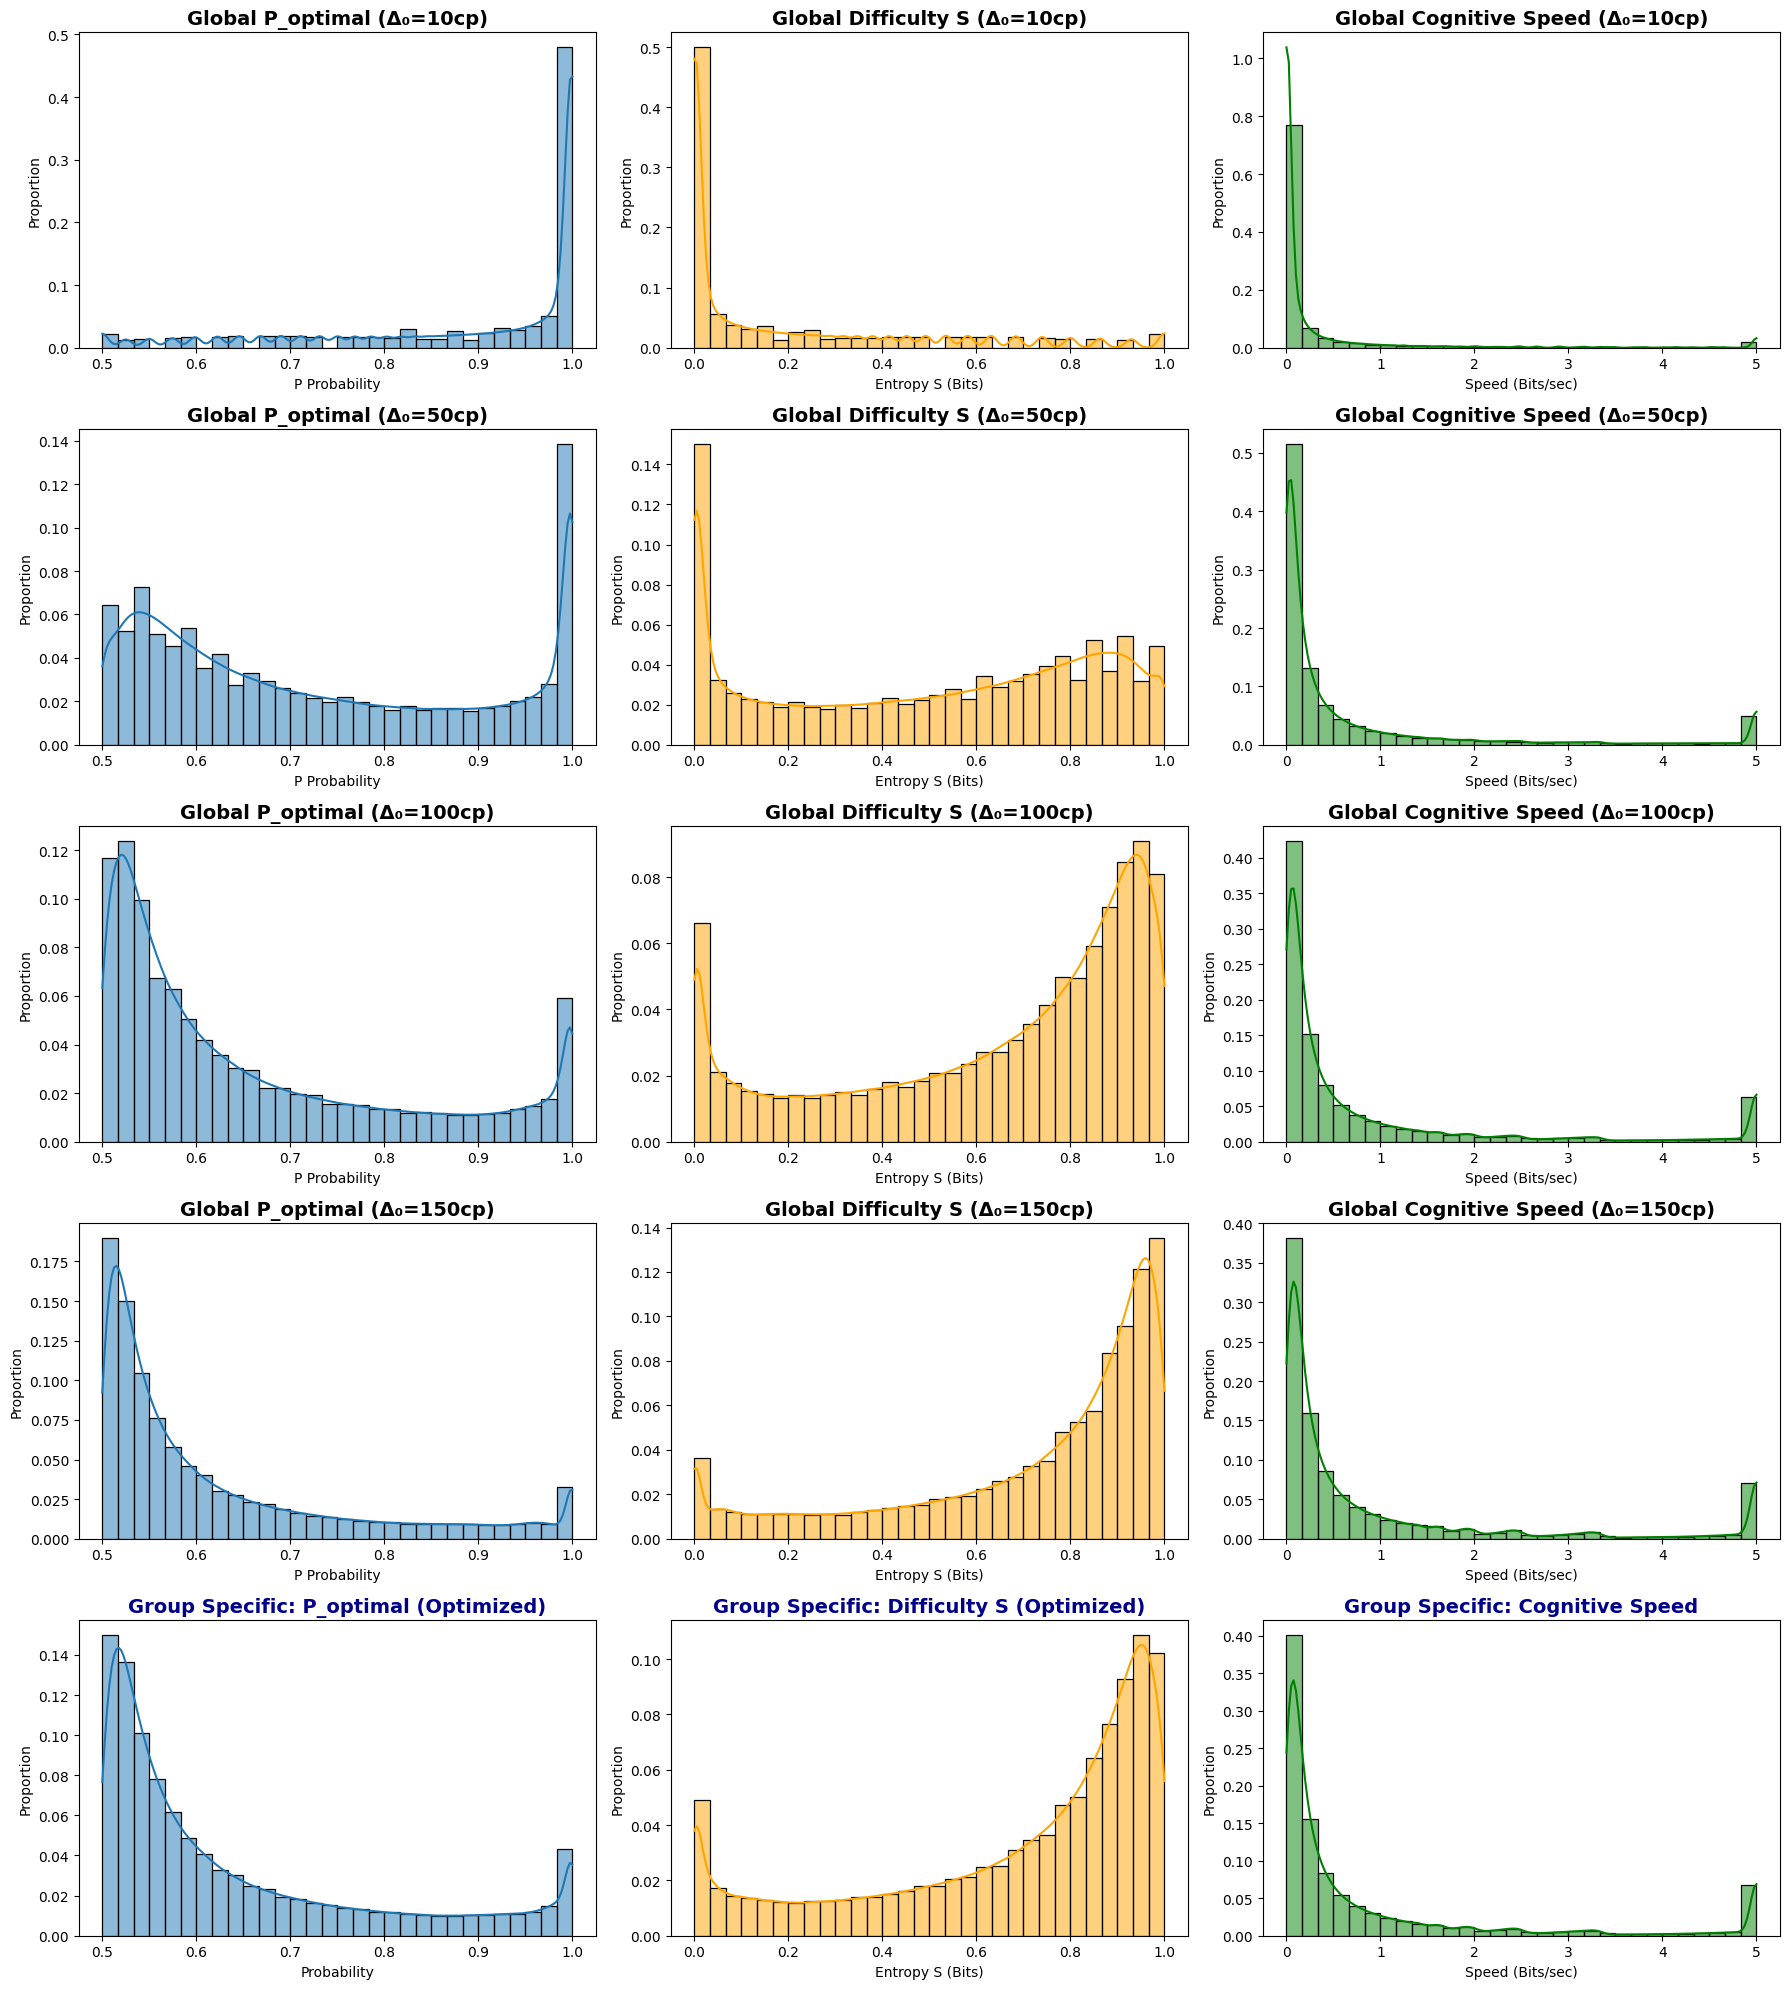

In [10]:
# 定义要画的 Global 参数列表
GLOBAL_DELTA_0_List = [10.0, 50.0, 100.0, 150.0]

# 计算总行数：Global 的数量 + 1 行 Group Specific
n_rows = len(GLOBAL_DELTA_0_List) + 1
n_cols = 3
#大画布
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))

# ---------------------------------------------------------
# 第一部分：循环绘制 Global 参数的分布 (前几行)
# ---------------------------------------------------------
# 列名匹配函数
def get_column_name(df, base_name, delta0):
    col_float = f'{base_name}(Global={delta0}cp)'
    col_int = f'{base_name}(Global={int(delta0)}cp)'
    return col_float if col_float in df.columns else col_int
for i, delta0 in enumerate(GLOBAL_DELTA_0_List):
    
    # 列名自动匹配 先尝试找带小数点的名字 (10.0cp)，如果找不到，就找整数名字 (10cp)    
    # 循环中调用函数
    p_col = get_column_name(complex_drop_opening, 'P_optimal', delta0)
    s_col = get_column_name(complex_drop_opening, 'S', delta0)
    speed_col = get_column_name(complex_drop_opening, 'Cognitive_Speed', delta0)
    # 检查是否真的找到了，避免再次报错
    if speed_col not in complex_drop_opening.columns:
        print(f"跳过: 找不到列 {speed_col} (请检查数据生成步骤的命名)")
        continue

    # 绘图
    # Col 1: P Distribution
    if p_col in complex_drop_opening.columns:
        sns.histplot(complex_drop_opening[p_col], bins=30, kde=True, ax=axes[i, 0], stat='probability')
        axes[i, 0].set_title(f'Global P_optimal (Δ₀={int(delta0)}cp)', fontsize=14, fontweight='bold')
        axes[i, 0].set_xlabel('P Probability')
        axes[i, 0].set_ylabel('Proportion')
    
    # Col 2: S Distribution
    if s_col in complex_drop_opening.columns:
        sns.histplot(complex_drop_opening[s_col], bins=30, kde=True, color='orange', ax=axes[i, 1], stat='probability')
        axes[i, 1].set_title(f'Global Difficulty S (Δ₀={int(delta0)}cp)', fontsize=14, fontweight='bold')
        axes[i, 1].set_xlabel('Entropy S (Bits)')
        axes[i, 1].set_ylabel('Proportion')
    
    # Col 3: Cognitive Speed
    if speed_col in complex_drop_opening.columns:
        sns.histplot(complex_drop_opening[speed_col].clip(upper=5), bins=30, kde=True, color='green', ax=axes[i, 2], stat='probability')
        axes[i, 2].set_title(f'Global Cognitive Speed (Δ₀={int(delta0)}cp)', fontsize=14, fontweight='bold')
        axes[i, 2].set_xlabel('Speed (Bits/sec)')
        axes[i, 2].set_ylabel('Proportion')

# ---------------------------------------------------------
# 第二部分：绘制 Group Specific 分布 (最后一行)
# ---------------------------------------------------------
last_row_idx = n_rows - 1

# 确保 Group 列存在， 一般这个存在另外的S和Speed也存在
if 'P_optimal' in complex_drop_opening.columns:
    # --- P Distribution ---
    sns.histplot(complex_drop_opening['P_optimal'], bins=30, kde=True, ax=axes[last_row_idx, 0], stat='probability')
    axes[last_row_idx, 0].set_title('Group Specific: P_optimal (Optimized)', fontsize=14, fontweight='bold', color='darkblue')
    axes[last_row_idx, 0].set_xlabel('Probability')
    axes[last_row_idx, 0].set_ylabel('Proportion')

    # --- S Distribution ---
    sns.histplot(complex_drop_opening['S'], bins=30, kde=True, color='orange', ax=axes[last_row_idx, 1], stat='probability')
    axes[last_row_idx, 1].set_title('Group Specific: Difficulty S (Optimized)', fontsize=14, fontweight='bold', color='darkblue')
    axes[last_row_idx, 1].set_xlabel('Entropy S (Bits)')
    axes[last_row_idx, 1].set_ylabel('Proportion')

    # --- Cognitive Speed ---
    sns.histplot(complex_drop_opening['Cognitive_Speed'].clip(upper=5), bins=30, kde=True, color='green', ax=axes[last_row_idx, 2], stat='probability')
    axes[last_row_idx, 2].set_title('Group Specific: Cognitive Speed', fontsize=14, fontweight='bold', color='darkblue')
    axes[last_row_idx, 2].set_xlabel('Speed (Bits/sec)')
    axes[last_row_idx, 2].set_ylabel('Proportion')
else:
    print("未找到 Group Specific 列 (P_optimal, S, Cognitive_Speed)，请检查是否已计算。")

plt.tight_layout()
plt.show()

In [11]:
time_complex.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),Delta0_Group,P_optimal,S,P_optimal(Global=10.0cp),S(Global=10.0cp),P_optimal(Global=50.0cp),S(Global=50.0cp),P_optimal(Global=100.0cp),S(Global=100.0cp),P_optimal(Global=150.0cp),S(Global=150.0cp),Cognitive_Speed(Global=10cp),Cognitive_Speed(Global=50cp),Cognitive_Speed(Global=100cp),Cognitive_Speed(Global=150cp),Cognitive_Speed
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),113.3,0.515441,0.956121,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730,0.447442,0.694264,0.731069,0.743638,0.735478
1,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),122.5,0.578926,0.788548,0.980160,0.028911,0.685680,0.544392,0.596283,0.745932,0.564636,0.824606,0.072278,1.360981,1.864829,2.061516,1.971371
2,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),113.3,0.535246,0.901726,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107,2.653127,7.875570,8.891961,9.251071,9.017261
3,5,34,6,Petar Ratkovic,Black,39,32,37,67,71,72,-,0,0,7.0,24.0,2463,2400-2600,0,1,178.3,Rich (>170),0.0,63,0.095238,Opening (0-33%),122.5,0.548824,0.865586,0.916827,0.125278,0.617748,0.694910,0.559714,0.837239,0.539915,0.889196,1.252781,6.949100,8.372392,8.891961,8.655858
4,8,34,9,Dennis Wagner,White,32,39,23,17,12,11,-,0,0,7.0,21.0,2802,2800-3000,0,1,179.6,Rich (>170),0.2,63,0.142857,Opening (0-33%),113.3,0.546205,0.872486,0.890903,0.166659,0.603483,0.728614,0.552308,0.856455,0.534943,0.902543,0.833297,3.643072,4.282277,4.512715,4.362428


In [12]:
complex_drop_opening.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),Delta0_Group,P_optimal,S,P_optimal(Global=10.0cp),S(Global=10.0cp),P_optimal(Global=50.0cp),S(Global=50.0cp),P_optimal(Global=100.0cp),S(Global=100.0cp),P_optimal(Global=150.0cp),S(Global=150.0cp),Cognitive_Speed(Global=10cp),Cognitive_Speed(Global=50cp),Cognitive_Speed(Global=100cp),Cognitive_Speed(Global=150cp),Cognitive_Speed
5,10,34,11,Dennis Wagner,White,42,50,40,29,26,18,-,0,0,8.0,18.0,2802,2800-3000,0,1,179.4,Rich (>170),0.9,63,0.174603,Opening (0-33%),113.3,0.539634,0.889946,0.858149,0.220700,0.589040,0.763561,0.544879,0.875992,0.529964,0.916034,0.245222,0.848402,0.973325,1.017815,0.988829
6,12,34,13,Dennis Wagner,White,56,66,58,48,35,28,-,0,0,10.0,19.0,2802,2800-3000,0,1,178.5,Rich (>170),2.8,63,0.206349,Opening (0-33%),113.3,0.541826,0.884098,0.869892,0.201093,0.593873,0.751773,0.547358,0.869444,0.531624,0.911521,0.071819,0.268491,0.310516,0.325543,0.315749
7,14,34,15,Dennis Wagner,White,58,70,55,29,28,27,-,0,0,12.0,31.0,2802,2800-3000,0,0,175.7,Rich (>170),0.3,63,0.238095,Opening (0-33%),113.3,0.567979,0.816091,0.956893,0.063571,0.650219,0.621003,0.576885,0.793644,0.551484,0.858610,0.211903,2.070011,2.645479,2.862034,2.720302
8,15,34,16,Petar Ratkovic,Black,80,58,69,72,81,90,-,0,0,22.0,16.0,2463,2400-2600,0,0,179.8,Rich (>170),0.8,63,0.253968,Opening (0-33%),122.5,0.532607,0.908857,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107,0.331641,0.984446,1.111495,1.156384,1.136072
9,16,34,17,Dennis Wagner,White,85,80,74,73,63,53,-,0,0,-5.0,11.0,2802,2800-3000,0,1,175.4,Rich (>170),6.5,63,0.269841,Opening (0-33%),113.3,0.524253,0.931665,0.750260,0.414537,0.554779,0.850014,0.527472,0.922833,0.518325,0.948071,0.063775,0.130771,0.141974,0.145857,0.143333


In [13]:
complex_drop_opening.columns

Index(['Unnamed: 0', 'uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2',
       'E3', 'E4', 'E5', 'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ',
       'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal', 'Remain_Time',
       'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'Delta0_Group', 'P_optimal', 'S',
       'P_optimal(Global=10.0cp)', 'S(Global=10.0cp)',
       'P_optimal(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_optimal(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_optimal(Global=150.0cp)', 'S(Global=150.0cp)',
       'Cognitive_Speed(Global=10cp)', 'Cognitive_Speed(Global=50cp)',
       'Cognitive_Speed(Global=100cp)', 'Cognitive_Speed(Global=150cp)',
       'Cognitive_Speed'],
      dtype='object')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\3325648691.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_data = (data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\3325648691.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_data = (data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\3325648691.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or ob

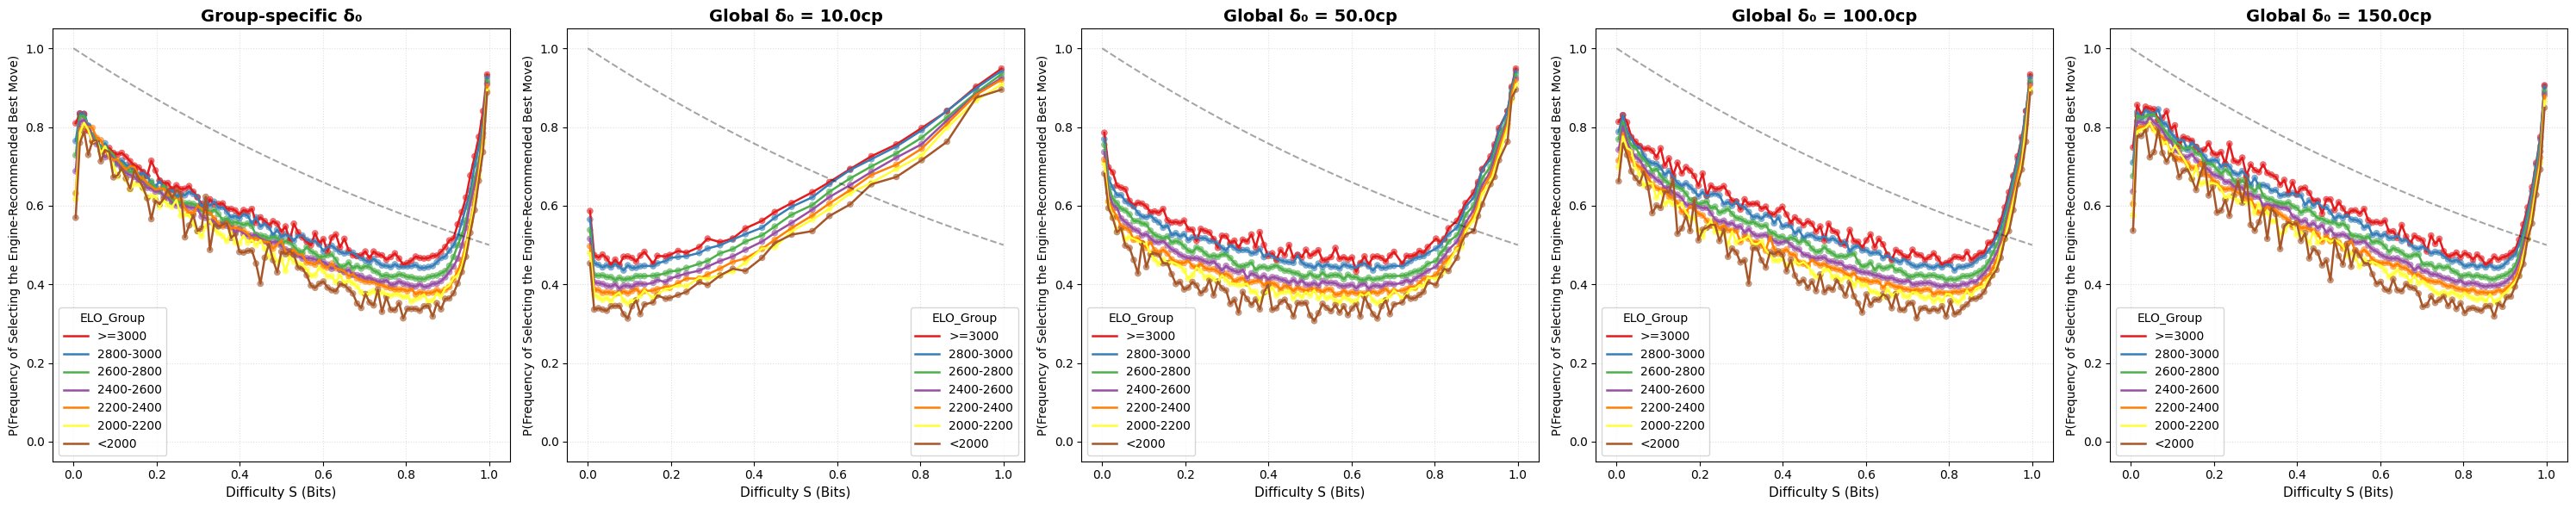

In [14]:
elo_order=['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000'] # 确保图例和曲线颜色从高到低一致

distinct_palette = sns.color_palette("Set1", len(elo_order))

def plot_difficulty_curve(data, x_col, title, ax):
    data = data.copy()
    
    # 分箱设置：100个分箱提供极高的精度
    s_min, s_max = data[x_col].min(), data[x_col].max()
    data['S_Bin'] = pd.cut(data[x_col], bins=np.linspace(s_min, s_max, 100)) 
    
    # 计算每个分箱的平均表现
    agg_data = (data.groupby(['ELO_Group', 'S_Bin'])['Is_Optimal']
                .mean().reset_index()
                .rename(columns={'Is_Optimal': 'Actual_Win_Rate'}))
    agg_data['S_Mid'] = agg_data['S_Bin'].apply(lambda x: x.mid)
    
    # 2. 绘制高精度散点 (高对比度颜色)
    sns.scatterplot(
        data=agg_data,
        x='S_Mid',
        y='Actual_Win_Rate',
        hue='ELO_Group',
        hue_order=elo_order,
        palette=distinct_palette,  # 应用高对比度配色
        s=25, 
        alpha=0.6,                 # 略微降低点透明度，突出折线
        ax=ax,
        edgecolor=None, 
        legend=False               # 由折线图控制图例
    )
    
    # 3. 叠加折线 (增强趋势感)
    sns.lineplot(
        data=agg_data,
        x='S_Mid',
        y='Actual_Win_Rate',
        hue='ELO_Group',
        hue_order=elo_order,
        palette=distinct_palette,
        linewidth=1.8,
        ax=ax,
        sort=True
    )
    
    # 4. 样式设置
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Difficulty S (Bits)', fontsize=11)
    
    # 修改纵坐标标签为你要求的详细版本
    ax.set_ylabel('P(Frequency of Selecting the Engine-Recommended Best Move)', fontsize=10)
    
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.4) 
    
    # 理论参考曲线 (2^-S)
    x_ref = np.linspace(s_min, s_max, 200)
    ax.plot(x_ref, 2 ** (-x_ref), 'k--', alpha=0.35, label='Theoretical ($2^{-S}$)')

# 绘图循环逻辑保持不变
fig, axes = plt.subplots(1, len(GLOBAL_DELTA_0_List) + 1, 
                         figsize=(6 * (len(GLOBAL_DELTA_0_List)+1), 6))

# 绘制 Group Δ0
plot_difficulty_curve(time_complex, x_col='S', title='Group-specific δ₀', ax=axes[0])

# 循环绘制 Global Δ0
for i, delta0 in enumerate(GLOBAL_DELTA_0_List):
    s_col = f'S(Global={delta0}cp)'
    plot_difficulty_curve(time_complex, x_col=s_col, title=f'Global δ₀ = {delta0}cp', ax=axes[i+1])

plt.tight_layout()
plt.show()

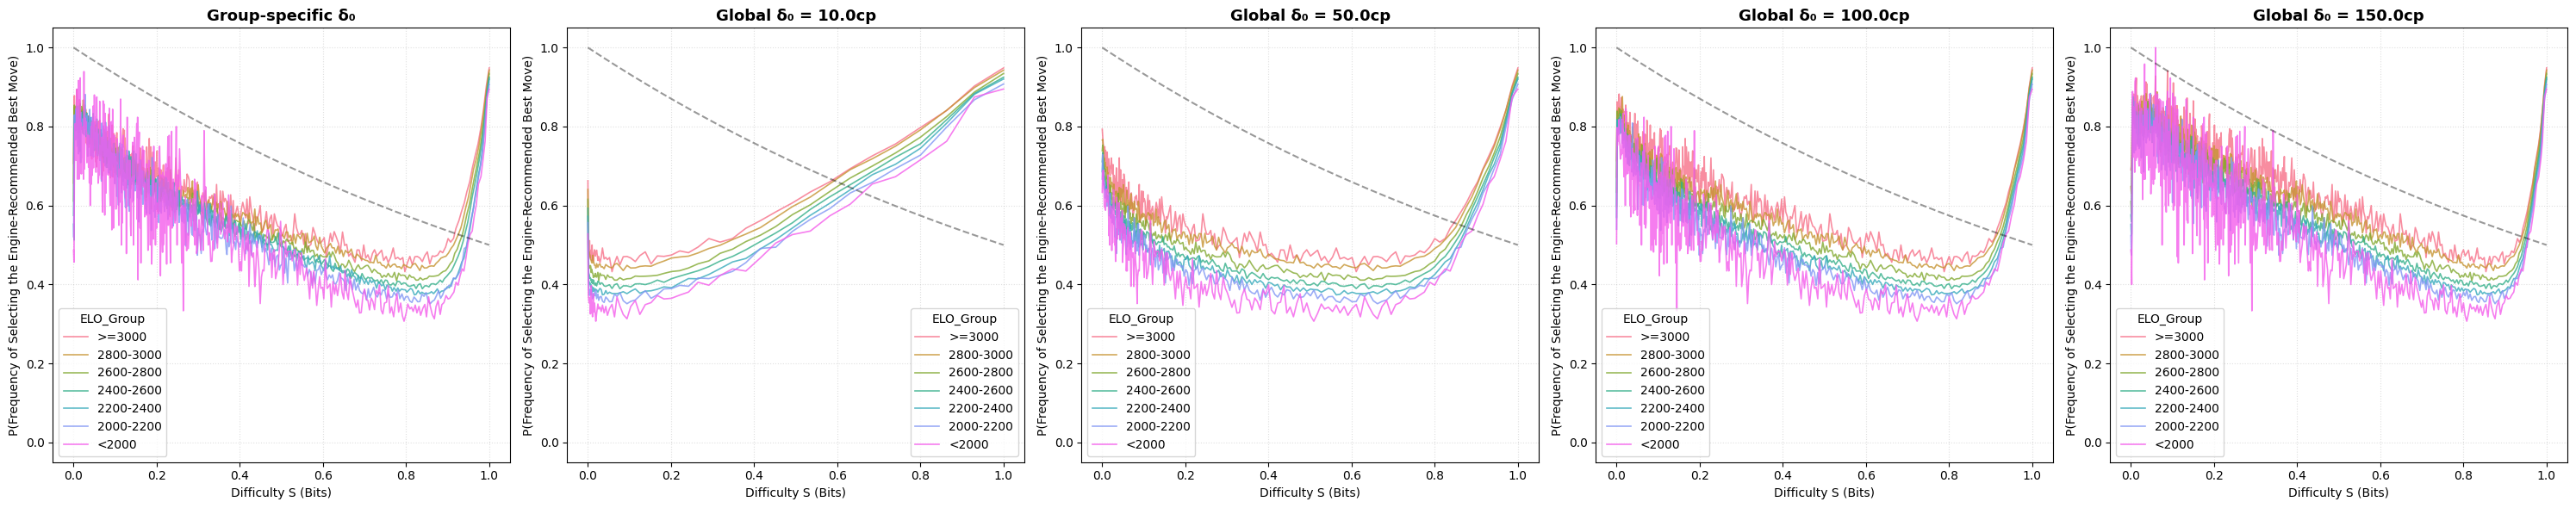

In [15]:
custom_palette = sns.color_palette("husl", len(elo_order))

def plot_difficulty_curve(data, x_col, title, ax):
    data = data.copy()
    
    # --- 核心修改：不再使用 pd.cut 分箱 ---
    # 如果 S 精度极高，建议简单四舍五入到 3 位小数，
    # 这样既保留了真实点，又能让极少数相同难度的局面合并计算概率。
    data['S_Real'] = data[x_col].round(3) 
    
    # 直接按真实出现的 S 值进行聚合
    agg_data = (
        data.groupby(['ELO_Group', 'S_Real'])['Is_Optimal']
        .mean()
        .reset_index()
        .rename(columns={'Is_Optimal': 'Actual_Win_Rate'})
    )
    
    # 绘制折线图：每一个真实的 S 点都会被画出来
    # 由于点非常多，建议减小标记 marker 的大小，甚至不显示 marker
    sns.lineplot(
        data=agg_data,
        x='S_Real',
        y='Actual_Win_Rate',
        hue='ELO_Group',
        hue_order=elo_order,
        palette=custom_palette, # 使用高区分度配色
        linewidth=1.2,          # 线条稍微细一点，适应高频波动
        alpha=0.8,
        ax=ax
    )
    
    # 样式微调
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Difficulty S (Bits)')
    ax.set_ylabel('P(Frequency of Selecting the Engine-Recommended Best Move)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=':', alpha=0.4)
    
    # 理论参考曲线：$P \approx 2^{-S}$
    x_ref = np.linspace(data[x_col].min(), data[x_col].max(), 300)
    ax.plot(x_ref, 2 ** (-x_ref), 'k--', alpha=0.4, label='Theory')

elo_order=['>=3000', '2800-3000', '2600-2800', '2400-2600', '2200-2400', '2000-2200', '<2000'] # 确保图例和曲线颜色从高到低一致


# GLOBAL_DELTA_0_List = [10, 50, 100, 150]
fig, axes = plt.subplots(1, len(GLOBAL_DELTA_0_List) + 1, 
                         figsize=(6 * (len(GLOBAL_DELTA_0_List)+1), 6))

# 画 Group Δ0
plot_difficulty_curve(
    time_complex,
    x_col='S',
    title='Group-specific δ₀',
    ax=axes[0]
)

# 画所有 Global
for i, delta0 in enumerate(GLOBAL_DELTA_0_List):
    s_col = f'S(Global={delta0}cp)'
    
    plot_difficulty_curve(
        time_complex,
        x_col=s_col,
        title=f'Global δ₀ = {delta0}cp',
        ax=axes[i+1]
    )

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\270199876.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\270199876.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\270199876.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\270199876.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

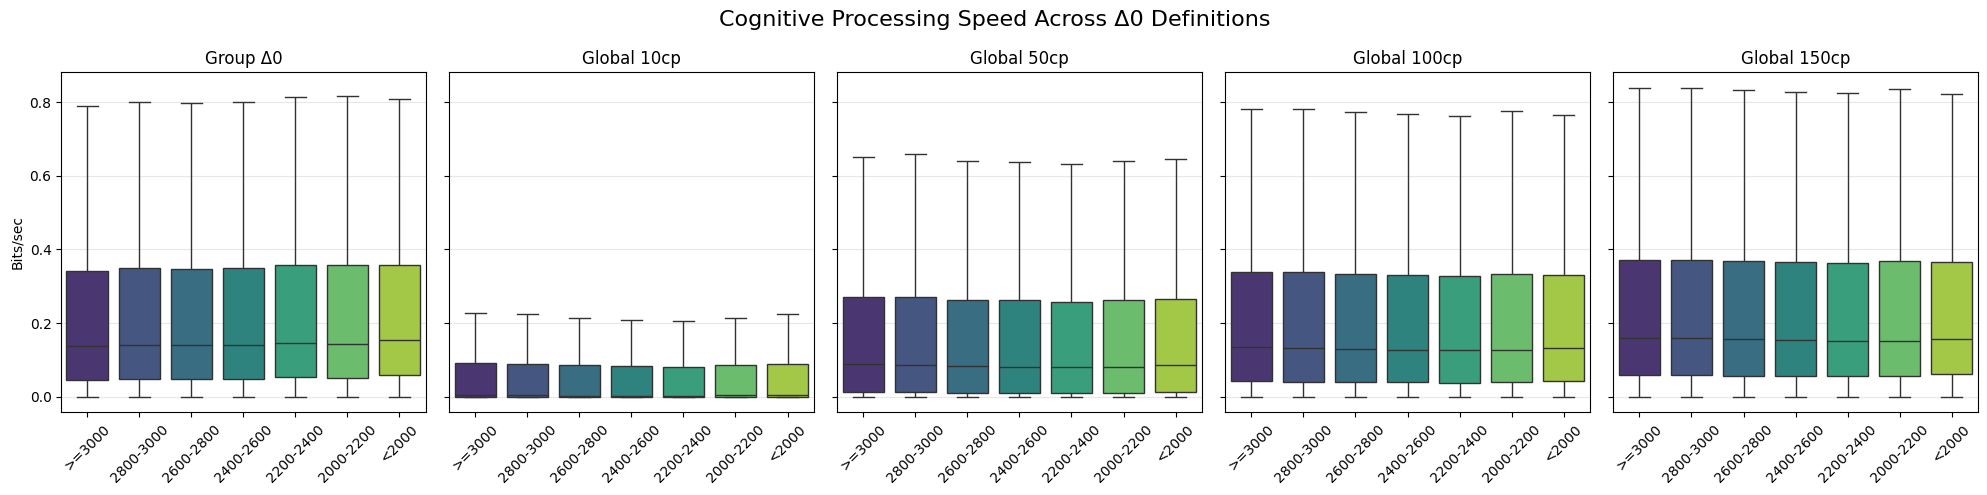

In [16]:
# 画的是筛选出走出最优解的图
# 总图数量 = 1 (group) + len(GLOBAL_DELTA_0_List)
n_plots = 1 + len(GLOBAL_DELTA_0_List)
fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 5), sharey=True)

# ----------------------------
# 1Group-specific
# ----------------------------
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed'] < 5 &  (complex_drop_opening['Is_Optimal'] == 1)].copy()

sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed',
    order=elo_order,
    palette='viridis',
    showfliers=False,   #是否显示离群点
    ax=axes[0]
)

axes[0].set_title('Group Δ0')
axes[0].set_xlabel('')
axes[0].set_ylabel('Bits/sec')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)


# ----------------------------
# 后面：Global Δ0
# ----------------------------
for i, delta in enumerate(GLOBAL_DELTA_0_List):

    delta_int = int(delta)
    col_name = f'Cognitive_Speed(Global={delta_int}cp)'
    
    speed_df = complex_drop_opening[ complex_drop_opening[col_name] < 5 &  (complex_drop_opening['Is_Optimal'] == 1)].copy()

    sns.boxplot(
        data=speed_df,
        x='ELO_Group',
        y=col_name,
        order=elo_order,
        palette='viridis',
        showfliers=False,    # 是否显示离群点
        ax=axes[i+1]
    )

    axes[i+1].set_title(f'Global {delta_int}cp')
    axes[i+1].set_xlabel('')
    axes[i+1].set_ylabel('')
    axes[i+1].tick_params(axis='x', rotation=45)
    axes[i+1].grid(axis='y', alpha=0.3)


plt.suptitle('Cognitive Processing Speed Across Δ0 Definitions', fontsize=16)
plt.tight_layout()
plt.show()


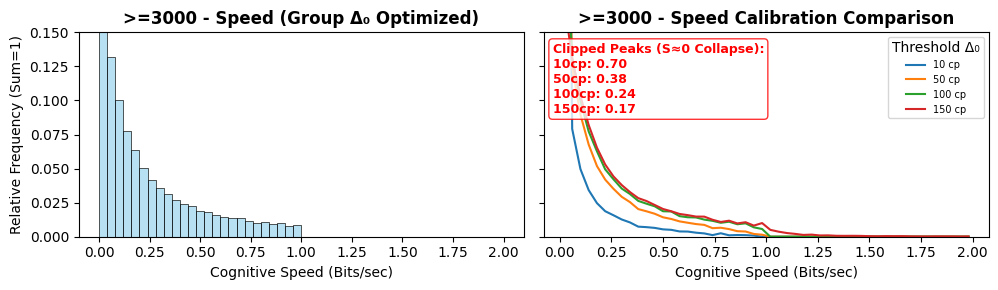

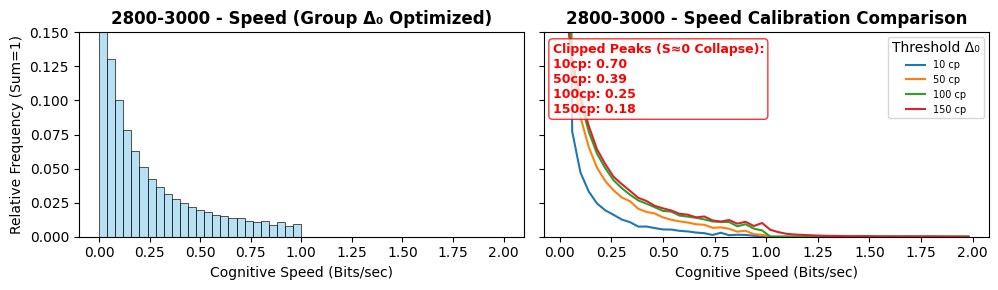

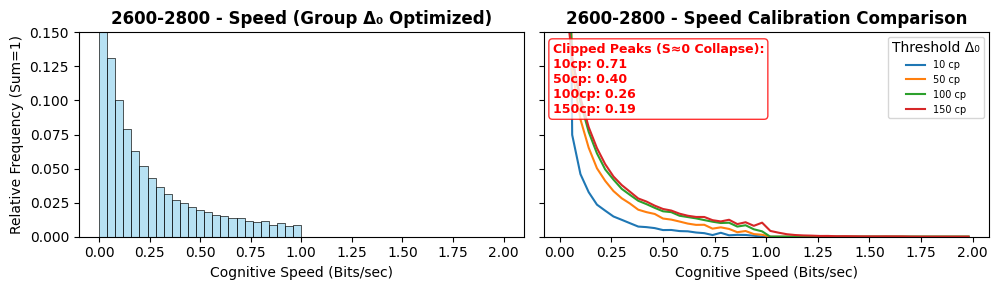

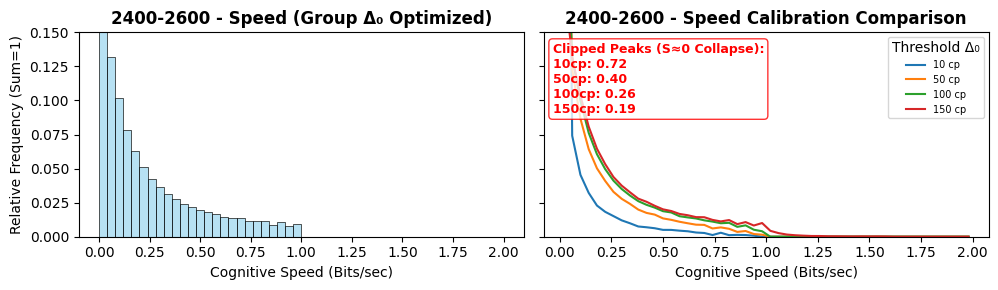

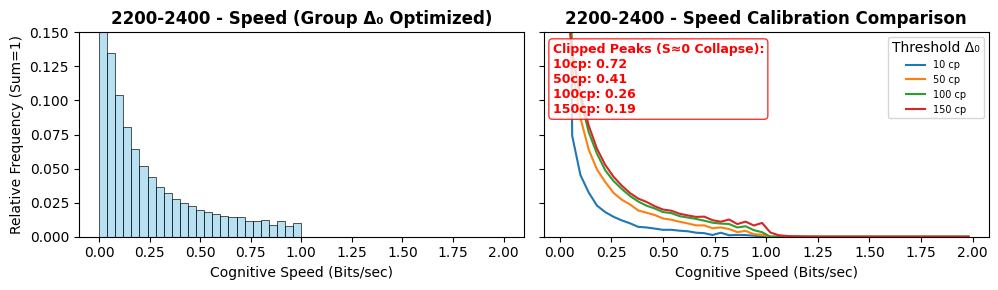

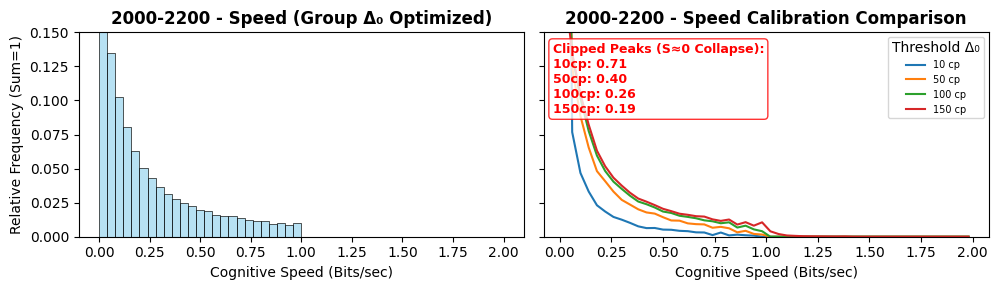

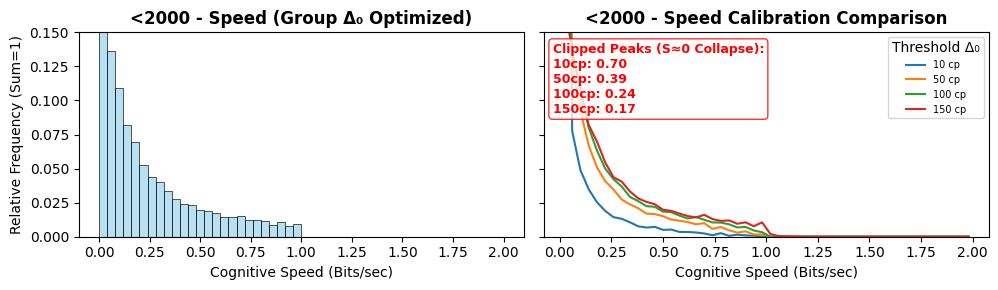

In [61]:
# 筛掉了做出正确决策的，和箱线图放一起，更详细点
def plot_cognitive_speed_final_version(df, elo_order, bins=50, y_limit=0.15):
    """
    认知速度对比图 强制统一物理量纲 (0-2.0 Bits/sec)，确保不同参数间具备学术可比性。
    """
    global_cols = [col for col in df.columns if col.startswith("Cognitive_Speed(Global=")]
    
    # 物理量纲定义：人类认知速度上限极少超过 2.0，设定此范围为“标准尺子”
    FIXED_MIN = 0.0
    FIXED_MAX = 2.0

    for elo in elo_order:
        sub_df = df[df['ELO_Group'] == elo]
        fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

        # ----------------------------
        # 优化模型 (Group Δ₀)
        # ----------------------------
        sns.histplot(
            sub_df['Cognitive_Speed'].dropna(),
            bins=bins, binrange=(FIXED_MIN, FIXED_MAX), # 统一分箱宽度
            stat='probability', ax=axes[0], color='skyblue', alpha=0.6
        )
        axes[0].set_ylim(0, y_limit)
        axes[0].set_title(f"{elo} - Speed (Group Δ₀ Optimized)", fontweight='bold')
        axes[0].set_xlabel("Cognitive Speed (Bits/sec)")
        axes[0].set_ylabel("Relative Frequency (Sum=1)")

        # ----------------------------
        # (Global Δ₀)
        # ----------------------------
        off_chart_peaks = []
        for col in global_cols:
            data = sub_df[col].dropna()
            sns.histplot(
                data, bins=bins, binrange=(FIXED_MIN, FIXED_MAX), # 核心
                stat='probability', element='poly', fill=False, 
                ax=axes[1],
                label=col.replace("Cognitive_Speed(Global=", "").replace("cp)", "") + " cp",
                linewidth=1.5
            )
            
            counts, _ = np.histogram(data, bins=bins, range=(FIXED_MIN, FIXED_MAX))
            if len(data) > 0:
                max_prob = counts.max() / len(data)
                if max_prob > y_limit:
                    label = col.replace("Cognitive_Speed(Global=", "").replace("cp)", "")
                    off_chart_peaks.append(f"{label}cp: {max_prob:.2f}")

        axes[1].set_xlabel("Cognitive Speed (Bits/sec)")
        axes[1].set_title(f"{elo} - Speed Calibration Comparison", fontweight='bold')
        axes[1].legend(fontsize=7, loc='upper right', title="Threshold Δ₀")

        if off_chart_peaks:
            ann_text = "Clipped Peaks (S≈0 Collapse):\n" + "\n".join(off_chart_peaks)
            axes[1].annotate(
                ann_text, xy=(0.02, 0.95), xycoords='axes fraction', 
                color='red', weight='bold', va='top', fontsize=9, 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8)
            )

        plt.tight_layout()
        plt.show()
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed'] < 5 &  (complex_drop_opening['Is_Optimal'] == 1)].copy()

plot_cognitive_speed_final_version(df=speed_df, elo_order=elo_order, bins=50, y_limit=0.15)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\1118783648.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\1118783648.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\1118783648.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\1118783648.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.

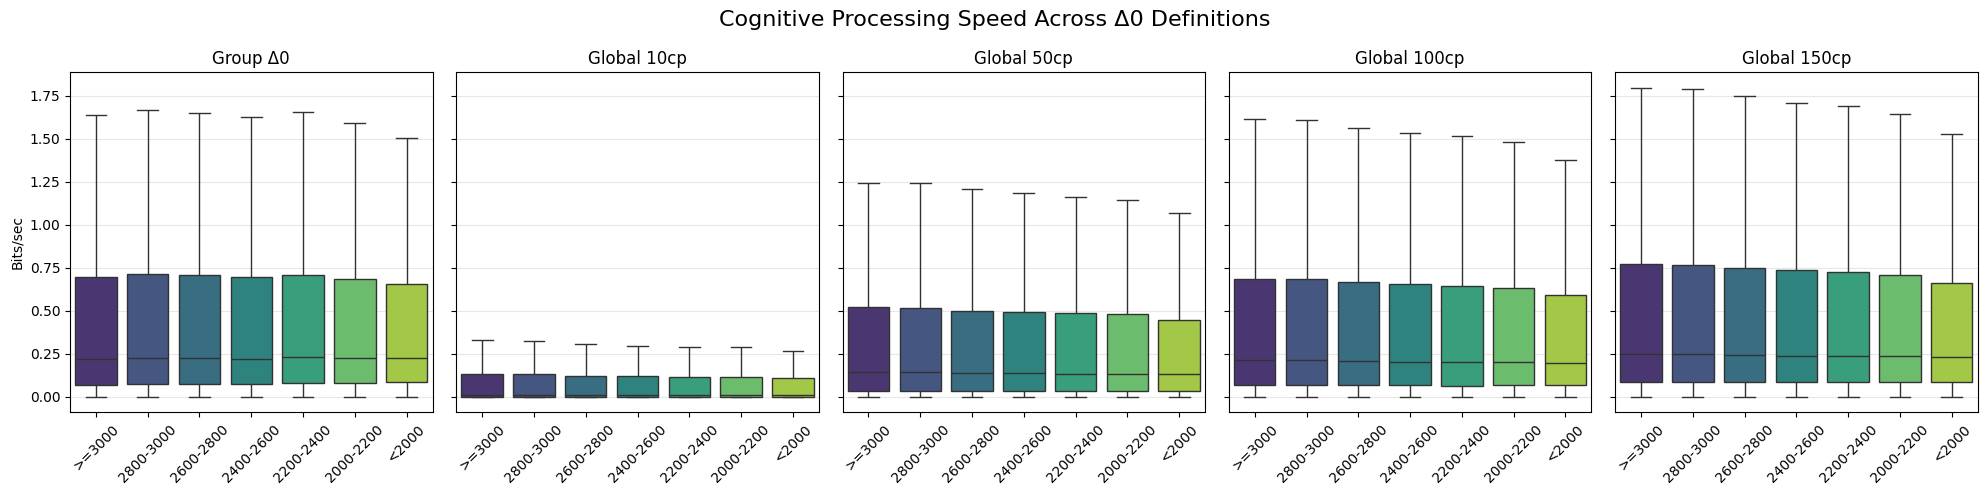

In [18]:
#  没有筛选出走出最优解的图，不太好
# 总图数量 = 1 (group) + len(GLOBAL_DELTA_0_List)
n_plots = 1 + len(GLOBAL_DELTA_0_List)
fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 5), sharey=True)

# ----------------------------
# 1Group-specific
# ----------------------------
speed_df = complex_drop_opening[complex_drop_opening['Cognitive_Speed'] < 5].copy()

sns.boxplot(
    data=speed_df,
    x='ELO_Group',
    y='Cognitive_Speed',
    order=elo_order,
    palette='viridis',
    showfliers=False,   #是否显示离群点
    ax=axes[0]
)

axes[0].set_title('Group Δ0')
axes[0].set_xlabel('')
axes[0].set_ylabel('Bits/sec')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)


# ----------------------------
# 后面：Global Δ0
# ----------------------------
for i, delta in enumerate(GLOBAL_DELTA_0_List):

    delta_int = int(delta)
    col_name = f'Cognitive_Speed(Global={delta_int}cp)'
    
    speed_df = complex_drop_opening[ complex_drop_opening[col_name] < 5].copy()

    sns.boxplot(
        data=speed_df,
        x='ELO_Group',
        y=col_name,
        order=elo_order,
        palette='viridis',
        showfliers=False,    # 是否显示离群点
        ax=axes[i+1]
    )

    axes[i+1].set_title(f'Global {delta_int}cp')
    axes[i+1].set_xlabel('')
    axes[i+1].set_ylabel('')
    axes[i+1].tick_params(axis='x', rotation=45)
    axes[i+1].grid(axis='y', alpha=0.3)


plt.suptitle('Cognitive Processing Speed Across Δ0 Definitions', fontsize=16)
plt.tight_layout()
plt.show()


棋局复杂度与棋手失误类型的关系

# Complexity 高低 → Blunder / Mistake 发生概率

In [19]:
pd.set_option('display.max_columns', None)
complex_drop_opening.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),Delta0_Group,P_optimal,S,P_optimal(Global=10.0cp),S(Global=10.0cp),P_optimal(Global=50.0cp),S(Global=50.0cp),P_optimal(Global=100.0cp),S(Global=100.0cp),P_optimal(Global=150.0cp),S(Global=150.0cp),Cognitive_Speed(Global=10cp),Cognitive_Speed(Global=50cp),Cognitive_Speed(Global=100cp),Cognitive_Speed(Global=150cp),Cognitive_Speed
5,10,34,11,Dennis Wagner,White,42,50,40,29,26,18,-,0,0,8.0,18.0,2802,2800-3000,0,1,179.4,Rich (>170),0.9,63,0.174603,Opening (0-33%),113.3,0.539634,0.889946,0.858149,0.220700,0.589040,0.763561,0.544879,0.875992,0.529964,0.916034,0.245222,0.848402,0.973325,1.017815,0.988829
6,12,34,13,Dennis Wagner,White,56,66,58,48,35,28,-,0,0,10.0,19.0,2802,2800-3000,0,1,178.5,Rich (>170),2.8,63,0.206349,Opening (0-33%),113.3,0.541826,0.884098,0.869892,0.201093,0.593873,0.751773,0.547358,0.869444,0.531624,0.911521,0.071819,0.268491,0.310516,0.325543,0.315749
7,14,34,15,Dennis Wagner,White,58,70,55,29,28,27,-,0,0,12.0,31.0,2802,2800-3000,0,0,175.7,Rich (>170),0.3,63,0.238095,Opening (0-33%),113.3,0.567979,0.816091,0.956893,0.063571,0.650219,0.621003,0.576885,0.793644,0.551484,0.858610,0.211903,2.070011,2.645479,2.862034,2.720302
8,15,34,16,Petar Ratkovic,Black,80,58,69,72,81,90,-,0,0,22.0,16.0,2463,2400-2600,0,0,179.8,Rich (>170),0.8,63,0.253968,Opening (0-33%),122.5,0.532607,0.908857,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107,0.331641,0.984446,1.111495,1.156384,1.136072
9,16,34,17,Dennis Wagner,White,85,80,74,73,63,53,-,0,0,-5.0,11.0,2802,2800-3000,0,1,175.4,Rich (>170),6.5,63,0.269841,Opening (0-33%),113.3,0.524253,0.931665,0.750260,0.414537,0.554779,0.850014,0.527472,0.922833,0.518325,0.948071,0.063775,0.130771,0.141974,0.145857,0.143333


In [21]:
df_moves.columns

Index(['Unnamed: 0', 'uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2',
       'E3', 'E4', 'E5', 'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ',
       'ELO', 'ELO_Group', 'Is_Forced', 'Is_Optimal', 'Remain_Time',
       'Time_Group', 'Move_Time', 'Game_Length', 'Progress',
       'Relative_Stage(temp)', 'Delta0_Group', 'P_optimal', 'S',
       'P_optimal(Global=10.0cp)', 'S(Global=10.0cp)',
       'P_optimal(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_optimal(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_optimal(Global=150.0cp)', 'S(Global=150.0cp)'],
      dtype='object')

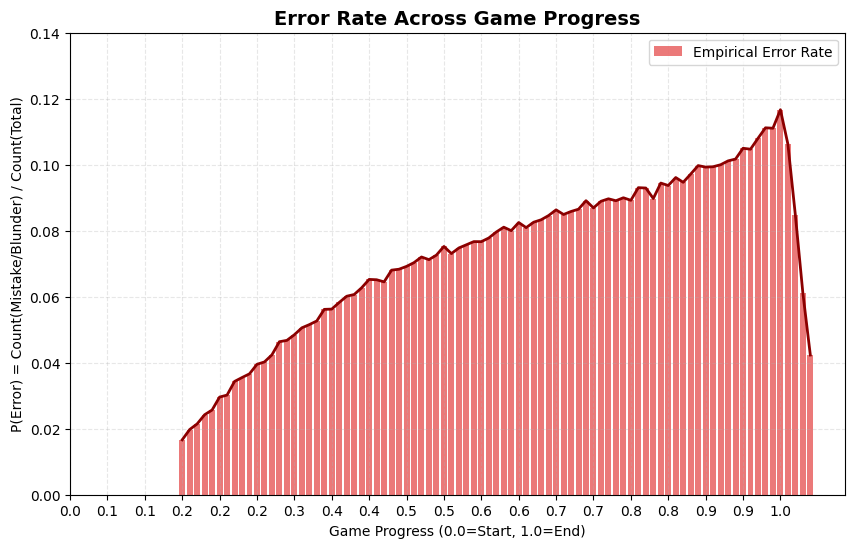

In [33]:
def plot_error_rate_by_progress(df, bins=50):
    """绘制不同对局进度下的错误率曲线"""
    
    # 1. 对 Progress 进行分箱
    # 确保我们统计的是全量数据（包含正确和错误）
    df = df.copy()
    s_min, s_max = 0, 1 # Progress 在 0-1 之间
    bin_edges = np.linspace(s_min, s_max, bins + 1)
    df['Progress_Bin'] = pd.cut(df['Progress'], bins=bin_edges)
    
    # 2. 分组计算：总步数 和 错误步数
    # 假设 Is_Error 列中 1 代表错误，0 代表正确
    group_stats = df.groupby('Progress_Bin', observed=False)['Is_Error'].agg(['count', 'sum']).reset_index()
    group_stats.columns = ['Bin', 'Total_Moves', 'Error_Moves']
    
    # 3. 计算错误率
    # 避免分母为 0
    group_stats['Error_Rate'] = group_stats['Error_Moves'] / group_stats['Total_Moves']
    group_stats['Bin_Mid'] = group_stats['Bin'].apply(lambda x: x.mid)
    
    # 4. 绘图
    plt.figure(figsize=(10, 6))
    
    # 绘制柱状图表示错误率
    sns.barplot(
        data=group_stats, 
        x='Bin_Mid', 
        y='Error_Rate', 
        color='red', 
        alpha=0.6,
        label='Empirical Error Rate'
    )
    
    # 叠加一条平滑的折线图
    sns.lineplot(
        data=group_stats, 
        x=np.arange(len(group_stats)), # barplot 的 x 轴默认是类别索引
        y='Error_Rate', 
        color='darkred', 
        linewidth=2
    )
    
    plt.title("Error Rate Across Game Progress", fontsize=14, fontweight='bold')
    plt.xlabel("Game Progress (0.0=Start, 1.0=End)")
    plt.ylabel("P(Error) = Count(Mistake/Blunder) / Count(Total)")
    
    # 优化坐标轴：因为 barplot x 轴比较挤，我们只显示部分标签
    plt.xticks(ticks=np.arange(0, bins, 5), labels=[f"{x:.1f}" for x in np.linspace(0, 1, bins // 5 + 1)[:-1]])
    
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.ylim(0, group_stats['Error_Rate'].max() * 1.2)
    plt.show()

plot_error_rate_by_progress(complex_drop_opening, bins=100)

In [34]:
total_moves = len(complex_drop_opening)
total_errors = complex_drop_opening['Is_Error'].sum()
overall_error_rate = total_errors / total_moves

print(f"总步数: {total_moves}")
print(f"总错误步数: {total_errors}")
print(f"整体错误率: {overall_error_rate:.2%}")

总步数: 5774179
总错误步数: 409868
整体错误率: 7.10%


=== Mistake / Blunder 's Game-Progress distribution 每个区间步数 ===
0.150-0.167: 2178              | 0.167-0.184: 2603
0.184-0.201: 3248              | 0.201-0.218: 3734
0.218-0.234: 4370              | 0.234-0.251: 4766
0.251-0.268: 5138              | 0.268-0.285: 5788
0.285-0.302: 6157              | 0.302-0.319: 6494
0.319-0.335: 6709              | 0.335-0.352: 7533
0.352-0.369: 7544              | 0.369-0.386: 7974
0.386-0.403: 8264              | 0.403-0.420: 8393
0.420-0.437: 8626              | 0.437-0.453: 8888
0.453-0.470: 8960              | 0.470-0.487: 9090
0.487-0.504: 8985              | 0.504-0.521: 9571
0.521-0.538: 9429              | 0.538-0.554: 9478
0.554-0.571: 9019              | 0.571-0.588: 9978
0.588-0.605: 10026             | 0.605-0.622: 9555
0.622-0.639: 9867              | 0.639-0.656: 9887
0.656-0.672: 9851              | 0.672-0.689: 9889
0.689-0.706: 10047             | 0.706-0.723: 9786
0.723-0.740: 9799              | 0.740-0.757: 9729
0.757-0.773: 9911  

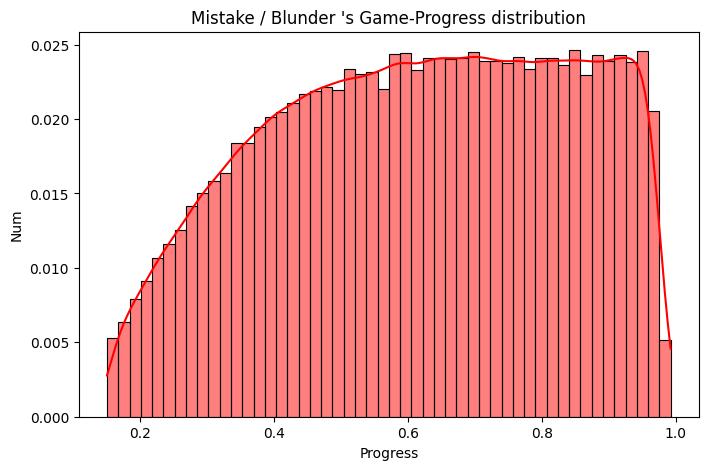

In [30]:
# 这张图好像没啥意义
def plot_hist_with_values(df, col, bins=50, kde=False, title=None, xlabel=None, ylabel='Relative Frequency (Probability)', color='blue'):
    """绘制直方图/柱状图并打印每个区间的具体步数。"""
    values = df[col].dropna()
    
    counts, bin_edges = np.histogram(values, bins=bins)
    
    print(f"=== {title if title else col} 每个区间步数 ===")
    for i in range(0, len(counts), 2):
        left = f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}: {counts[i]}"
        if i + 1 < len(counts):
            right = f"{bin_edges[i+1]:.3f}-{bin_edges[i+2]:.3f}: {counts[i+1]}"
            print(f"{left:<30} | {right}")
        else:
            print(left)

    plt.figure(figsize=(8,5))
    sns.histplot(values, bins=bins, kde=kde, color=color, stat='probability')
    plt.title(title if title else col)
    plt.xlabel(xlabel if xlabel else col)
    plt.ylabel(ylabel)
    plt.show() 
# mistake blunder distribution
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error']==1]

plot_hist_with_values(df=errors_df, col='Progress', bins=50, kde=True, title="Mistake / Blunder 's Game-Progress distribution", xlabel='Relative Frequency (Probability)', ylabel='Num',color='red')

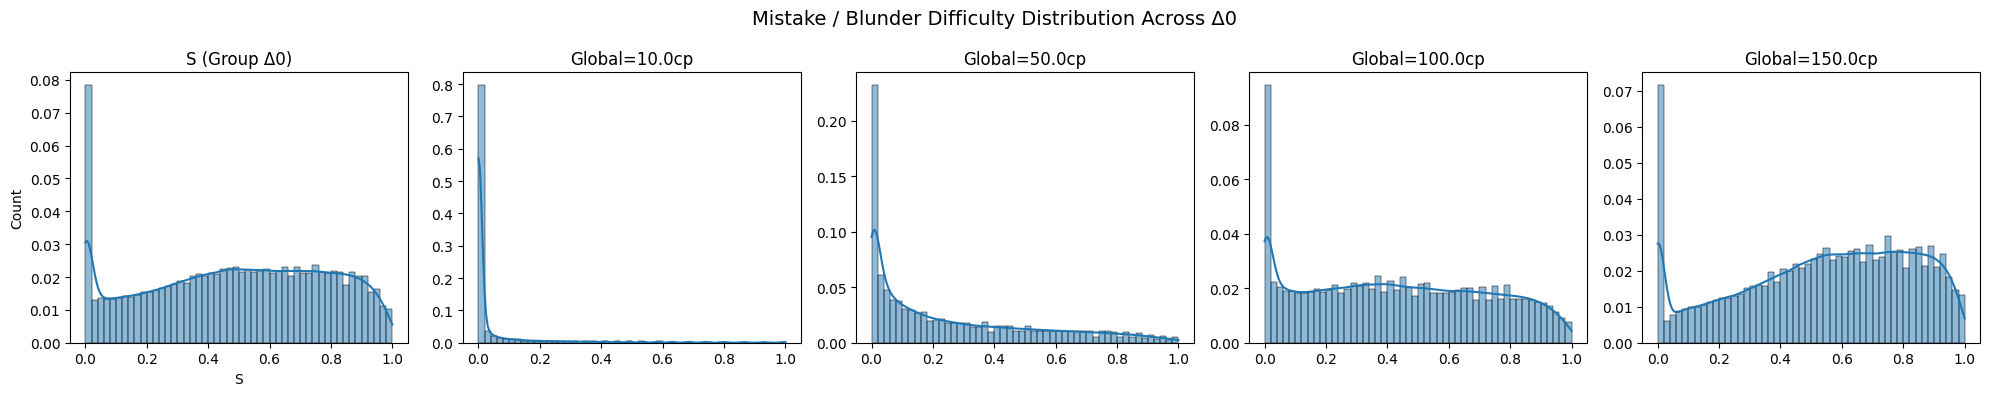

In [44]:
# 只保留错误步
errors_df = complex_drop_opening[complex_drop_opening['Is_Error'] == 1].copy()
# 自动找所有 Global S 列
global_s_cols = [col for col in errors_df.columns if col.startswith('S(Global=')]

# 总图数量
n_plots = 1 + len(global_s_cols)

fig, axes = plt.subplots(1, n_plots, figsize=(4*n_plots, 4), sharey=False)

# ----------------------------
# Group-specific S
# ----------------------------
sns.histplot(
    errors_df['S'].dropna(),
    bins=50,
    kde=True,
    stat="probability",
    ax=axes[0]
)

axes[0].set_title("S (Group Δ0)")
axes[0].set_xlabel("S")
axes[0].set_ylabel("Count")


# ----------------------------
# Global S
# ----------------------------
for i, col in enumerate(global_s_cols):

    sns.histplot(
        errors_df[col].dropna(),
        bins=50,
        kde=True,
        stat="probability",
        ax=axes[i+1]
    )

    axes[i+1].set_title(col.replace("S(", "").replace(")", ""))
    axes[i+1].set_xlabel("")
    axes[i+1].set_ylabel("")

plt.suptitle("Mistake / Blunder Difficulty Distribution Across Δ0", fontsize=14)
plt.tight_layout()
plt.show()


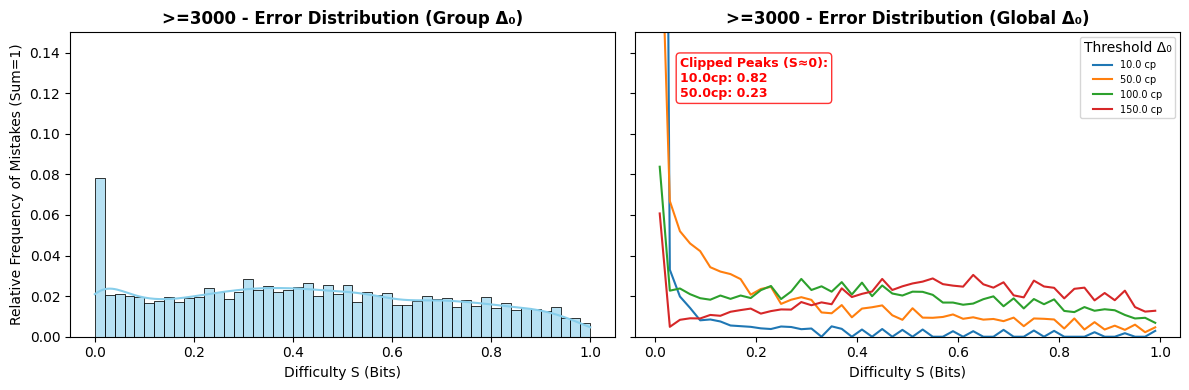

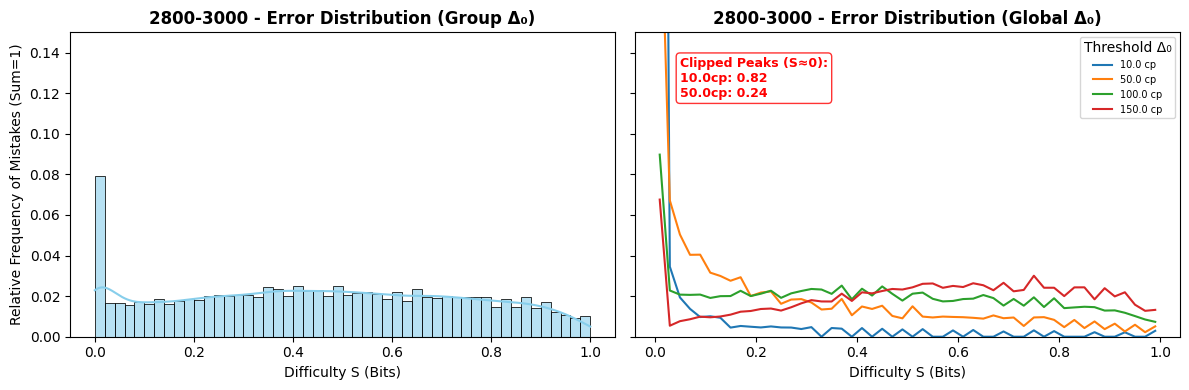

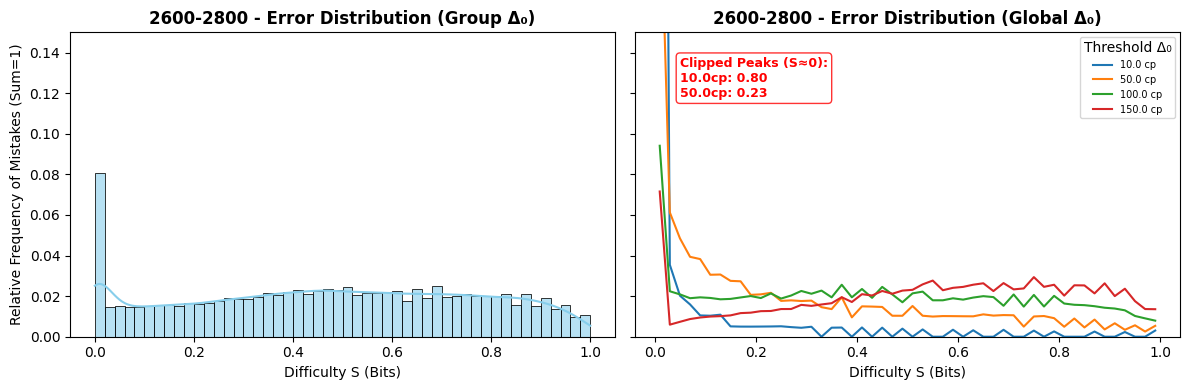

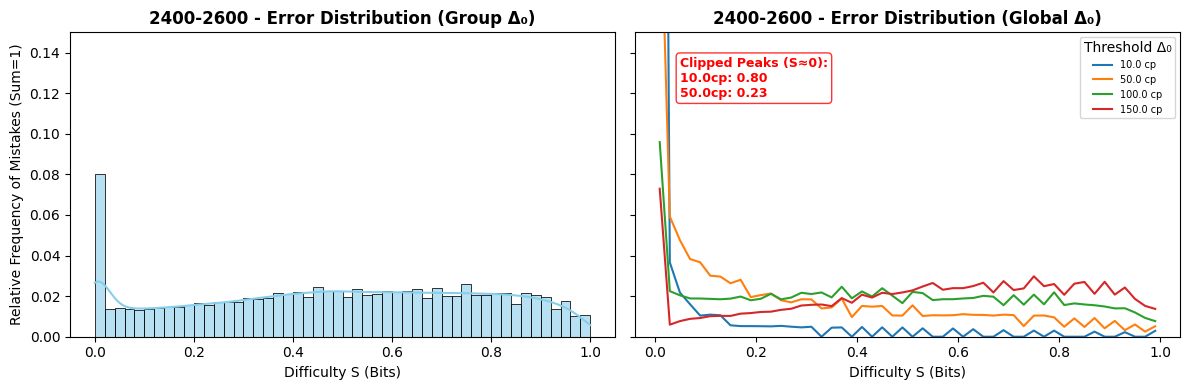

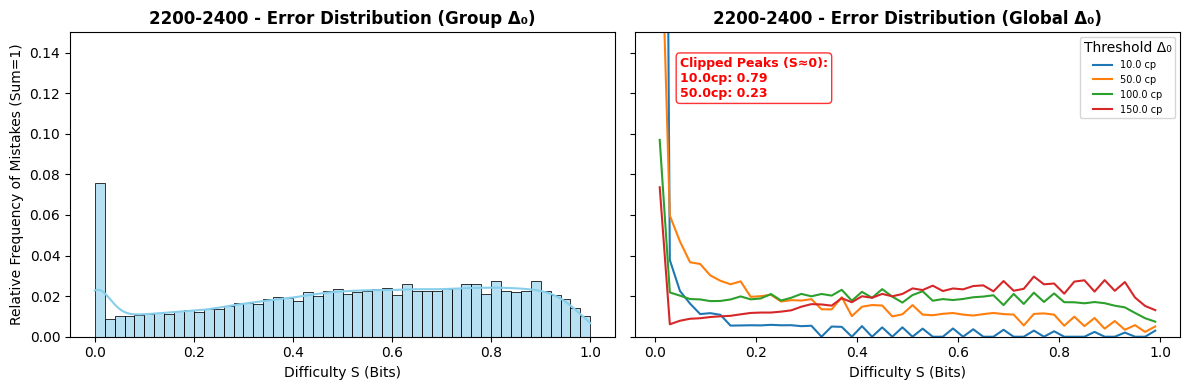

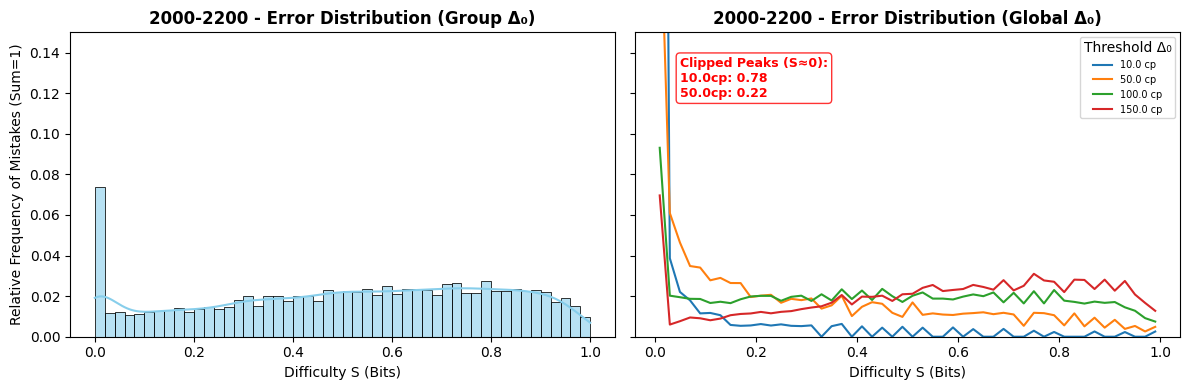

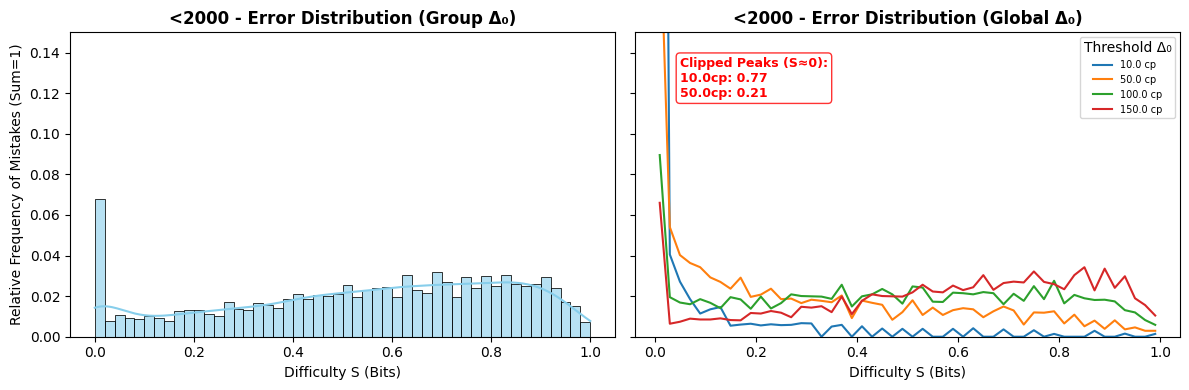

In [43]:
def plot_hist_compare_by_elo(df, elo_order, bins=50, kde=True):
    # 这个函数是对数画图，但感觉不好看，所以用的还是下面那个函数
    global_cols = [col for col in df.columns if col.startswith("S(Global=")]

    for elo in elo_order:
        # 筛选特定等级分群体的数据
        sub_df = df[df['ELO_Group'] == elo]

        # 开启 sharey=True 使得左右两图的纵坐标量程完全一致，方便直观对比
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

        # ----------------------------
        # 左图：Group-specific S (反映该组优化后的复杂度分布)
        # ----------------------------
        sns.histplot(
            sub_df['S'].dropna(),
            bins=bins,
            kde=kde,
            stat='probability', # 纵坐标改为概率(占比)
            ax=axes[0],
            color='skyblue',
            label='Group-specific S',
            alpha=0.6
        )
        axes[0].set_title(f"{elo} - S (Group Specific)", fontweight='bold')
        axes[0].set_xlabel("Complexity S (Bits)")
        axes[0].set_ylabel("Relative Frequency (Sum=1)") # 明确标注纵轴含义

        # ----------------------------
        # 右图：叠加所有 Global Δ0 (对比不同参数下的概率分布)
        # ----------------------------
        for col in global_cols:
            # 使用 element='poly' 将柱状图转为折线，stat='probability' 保证总和为 1
            sns.histplot(
                sub_df[col].dropna(),
                bins=bins,
                stat='probability',
                element='poly',  # 关键：将直方图改为折线模式，方便多线叠加
                fill=False,      # 关键：不填充颜色，避免遮挡
                ax=axes[1],
                label=col.replace("S(", "").replace(")", ""), # 简化标签
                linewidth=1.5
            )

        axes[1].set_title(f"{elo} - Global Δ0 Comparison", fontweight='bold')
        axes[1].set_xlabel("Complexity S (Bits)")
        axes[1].set_ylabel("Relative Frequency (Sum=1)")
        axes[1].legend(fontsize=7, title="Δ0 Setup", loc='upper right')
        axes[0].set_yscale('log')
        axes[1].set_yscale('log')
        # 注意：使用对数轴时 ylim 底部不能为 0，建议设为 0.001
        axes[0].set_ylim(0.001, 1.0)

        plt.tight_layout()
        plt.show()

def plot_hist_compare_by_elo(df, elo_order, bins=50, kde=True, y_limit=0.15): # 增加 y_limit 参数

    global_cols = [col for col in df.columns if col.startswith("S(Global=")]

    for elo in elo_order:
        sub_df = df[df['ELO_Group'] == elo]
        fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

        # --- 左图：Group-specific S ---
        sns.histplot(sub_df['S'].dropna(), bins=bins, kde=kde, stat='probability',
                     ax=axes[0], color='skyblue', alpha=0.6)
        axes[0].set_ylim(0, y_limit)
        axes[0].set_title(f"{elo} - Error Distribution (Group Δ₀)", fontweight='bold')
        axes[0].set_xlabel("Difficulty S (Bits)")
        axes[0].set_ylabel("Relative Frequency of Mistakes (Sum=1)")

        # --- 右图：Global Δ0 对比 ---
        off_chart_peaks = [] #存储越界的峰值信息
        
        for col in global_cols:
            data = sub_df[col].dropna()
            sns.histplot(data,bins=bins,stat='probability',element='poly', fill=False, ax=axes[1],label=col.replace("S(Global=", "").replace("cp)", "") + " cp",linewidth=1.5)
            
            # 计算峰值用于标注
            counts, _ = np.histogram(data, bins=bins, range=(0, 1))
            max_prob = counts.max() / len(data)
            if max_prob > y_limit:
                label = col.replace("S(Global=", "").replace("cp)", "")
                off_chart_peaks.append(f"{label}cp: {max_prob:.2f}")
        axes[1].set_xlabel("Difficulty S (Bits)")
        axes[1].set_title(f"{elo} - Error Distribution (Global Δ₀)", fontweight='bold')
        axes[1].legend(fontsize=7, loc='upper right', title="Threshold Δ₀")

        # 动态标注多个越界峰值
        if off_chart_peaks:
            ann_text = "Clipped Peaks (S≈0):\n" + "\n".join(off_chart_peaks)
            axes[1].annotate(
                ann_text, xy=(0.05, y_limit * 0.92), 
                xycoords='data', color='red', weight='bold',
                va='top', fontsize=9, 
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8)
            )

        plt.tight_layout()
        plt.show()

# 调用函数：传入你的错误步数据集
plot_hist_compare_by_elo(
    df=errors_df,
    elo_order=elo_order, # 使用你定义的 group_order
    bins=50,
    kde=True
)

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:17: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\341513592.py:14: SyntaxWarning: invalid escape sequence '\D'
  '(A) Literature Standard ($\Delta_0=10$cp)': 'S(Global=10.0cp)',
C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\341513592.py:15: SyntaxWarning: invalid escape sequence '\D'
  '(B) ($\Delta_0=50$cp)': 'S(Global=50.0cp)',
C:\Users\Administrator\AppData\Local

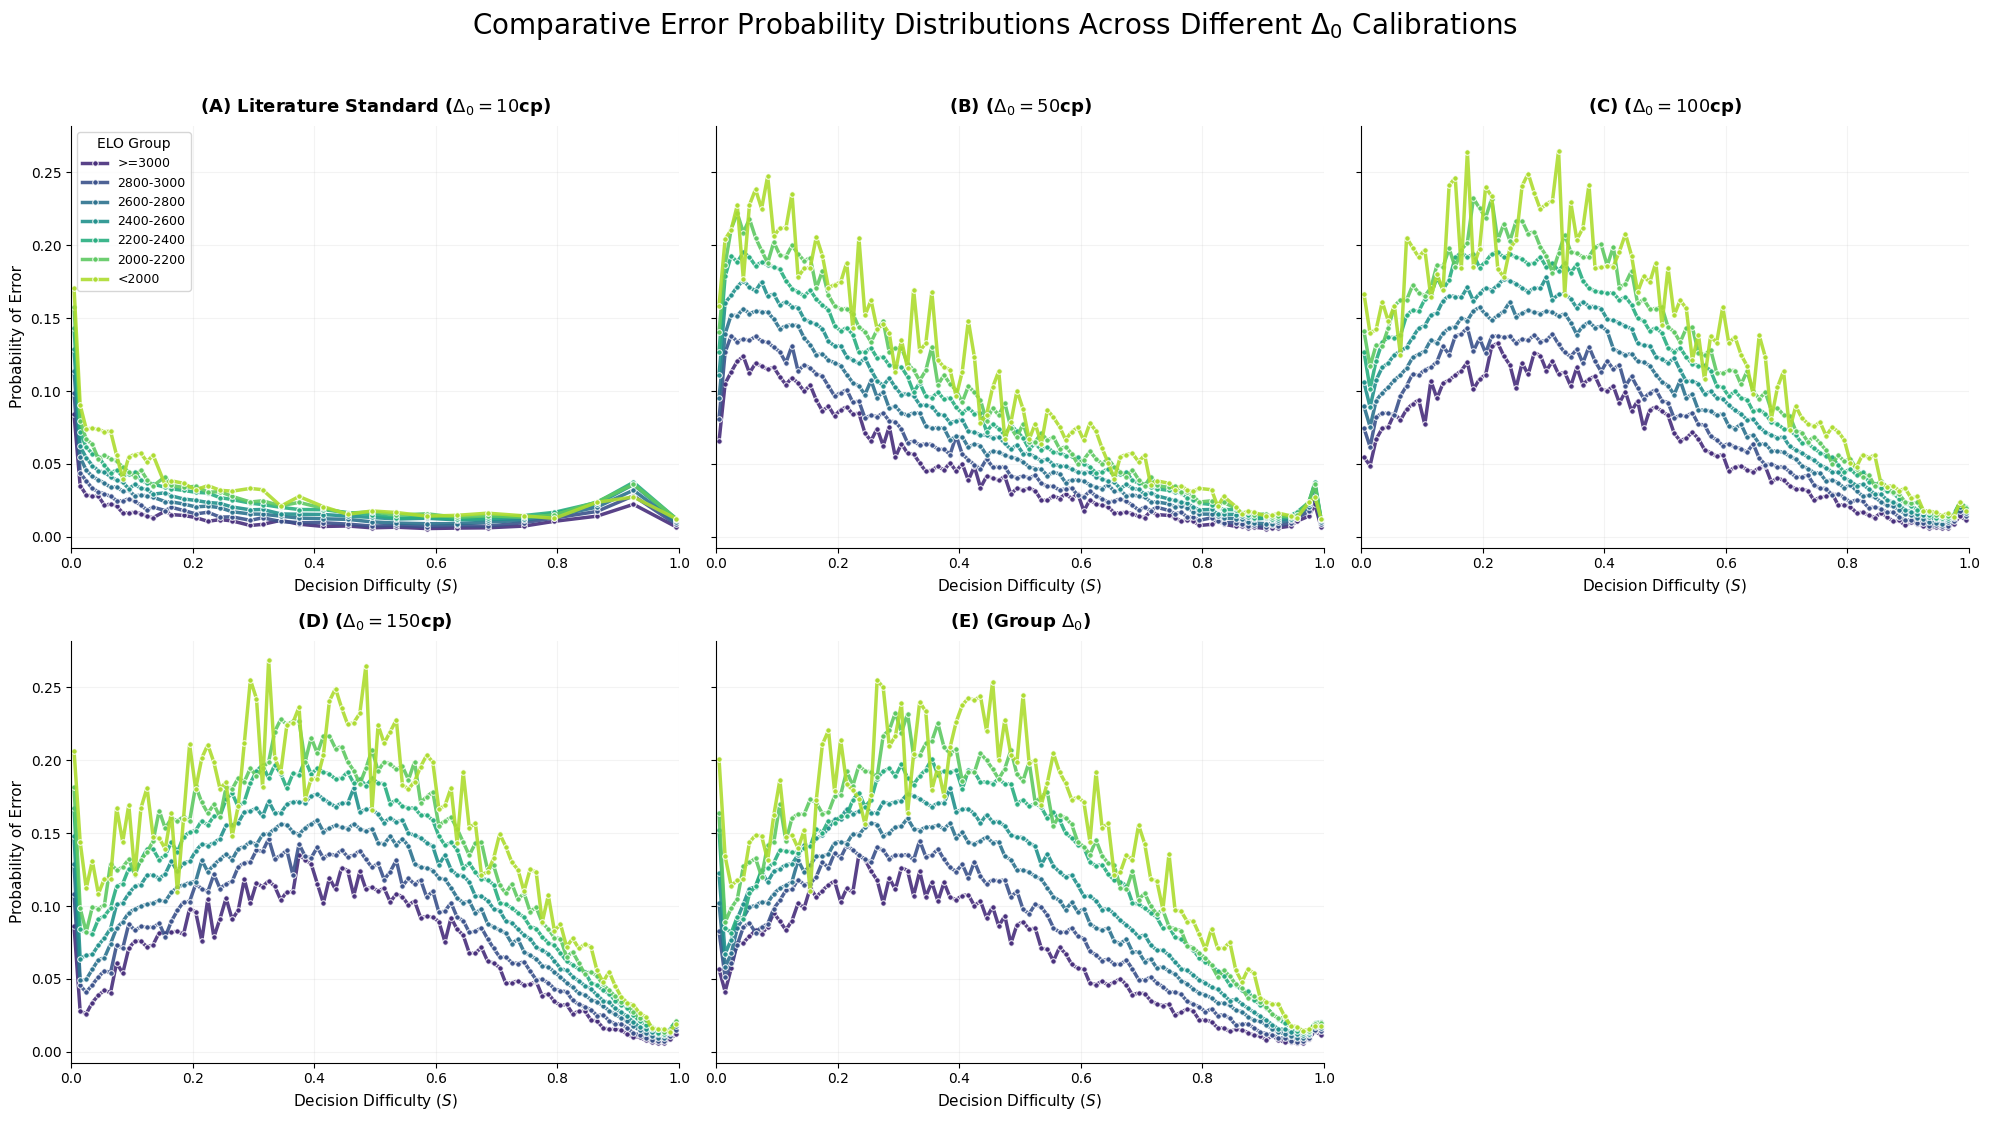

In [48]:
def plot_evolution_grid_high_res(df):
    # 数据筛选
    all_groups = [
        '>=3000', '2800-3000', '2600-2800', '2400-2600', 
        '2200-2400', '2000-2200', '<2000'
    ]
    plot_df = df[df['ELO_Group'].isin(all_groups)].copy()
    palette = 'viridis'
    subplots_map = {
        '(A) Literature Standard ($\Delta_0=10$cp)': 'S(Global=10.0cp)',
        '(B) ($\Delta_0=50$cp)': 'S(Global=50.0cp)',
        '(C) ($\Delta_0=100$cp)': 'S(Global=100.0cp)',
        '(D) ($\Delta_0=150$cp)': 'S(Global=150.0cp)',
        '(E) (Group $\Delta_0$)': 'S'
    }

    # --- 画布 ---
    fig, axes = plt.subplots(2, 3, figsize=(20, 12), sharey=True) 
    axes = axes.flatten()
    
    # nbins改为 50 或 80。越大越精确，但曲线会越抖动
    n_bins = 100 
    
    # --- 3. 循环绘图 ---
    for i, (title, col) in enumerate(subplots_map.items()):
        ax = axes[i]
        
        if col not in plot_df.columns:
            continue

        # 自然分成 100 个微小的区间
        # 或者用 cut，但 bins 设得很大
        plot_df[f'{col}_Bin'] = pd.cut(plot_df[col], bins=np.linspace(0, 1, n_bins+1))
        # 计算每个微元内的平均犯错率
        stats = plot_df.groupby(['ELO_Group', f'{col}_Bin'], observed=True)['Is_Error'].mean().reset_index()
        stats['X_Axis'] = stats[f'{col}_Bin'].apply(lambda x: x.mid)
        
        # 去掉空值（防止断线）
        stats = stats.dropna(subset=['Is_Error'])

        # 绘图参数调整
        sns.lineplot(
            data=stats, x='X_Axis', y='Is_Error', 
            hue='ELO_Group', hue_order=all_groups,
            palette=palette,
            ax=ax,
            linewidth=2.5,      # 线条稍微加粗
            marker='o',         # 保留点
            markersize=4,       # 点改小，让它看起来像一条连续的线
            dashes=False,       # 禁用虚线，全部实线
            alpha=0.9,          #稍微透明一点，增加层次感
            legend=(i==0)
        )
        
        ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel("Decision Difficulty ($S$)", fontsize=11)
        ax.set_xlim(0, 1.0)
        ax.grid(True, linestyle='-', alpha=0.15) 
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if i % 3 == 0:
            ax.set_ylabel("Probability of Error", fontsize=11)
        else:
            ax.set_ylabel("")
    if len(subplots_map) < len(axes):
        for j in range(len(subplots_map), len(axes)):
            fig.delaxes(axes[j])

    if axes[0].get_legend():
        axes[0].legend(title='ELO Group', fontsize=9, title_fontsize=10, loc='upper left')

    plt.suptitle("Comparative Error Probability Distributions Across Different $\Delta_0$ Calibrations", fontsize=20, y=0.96)
    plt.tight_layout(rect=[0, 0.03, 1, 0.94]) 
    plt.show()

# 运行
plot_evolution_grid_high_res(df_moves)

In [26]:
df_moves.head()

,Unnamed: 0,uid,Move_Idx,Player,Color,E,E1,E2,E3,E4,E5,Judgment_Raw,Is_Error,Is_Blunder,Δi,Δ,ELO,ELO_Group,Is_Forced,Is_Optimal,Remain_Time,Time_Group,Move_Time,Game_Length,Progress,Relative_Stage(temp),Delta0_Group,P_optimal,S,P_optimal(Global=10.0cp),S(Global=10.0cp),P_optimal(Global=50.0cp),S(Global=50.0cp),P_optimal(Global=100.0cp),S(Global=100.0cp),P_optimal(Global=150.0cp),S(Global=150.0cp)
0,0,34,1,Dennis Wagner,White,33,36,34,31,25,16,-,0,0,3.0,7.0,2802,2800-3000,0,1,179.8,Rich (>170),1.3,63,0.015873,Opening (0-33%),113.3,0.515441,0.956121,0.668188,0.581675,0.534943,0.902543,0.517493,0.950389,0.511665,0.966730
1,1,34,2,Petar Ratkovic,Black,36,33,34,34,42,48,-,0,0,3.0,4.0,2463,2400-2600,0,1,177.8,Rich (>170),-0.9,63,0.031746,Opening (0-33%),122.5,0.508163,0.976638,0.598688,0.740125,0.519989,0.943446,0.509999,0.971435,0.506666,0.980892
2,2,34,3,Dennis Wagner,White,30,36,33,27,25,20,-,0,0,6.0,8.0,2802,2800-3000,0,1,178.5,Rich (>170),-0.7,63,0.047619,Opening (0-33%),113.3,0.517645,0.949965,0.689974,0.535385,0.539915,0.889196,0.519989,0.943446,0.513330,0.962041
3,3,34,4,Petar Ratkovic,Black,44,30,63,66,78,79,-,0,0,14.0,39.0,2463,2400-2600,0,0,178.7,Rich (>170),0.4,63,0.063492,Opening (0-33%),122.5,0.578926,0.788548,0.980160,0.028911,0.685680,0.544392,0.596283,0.745932,0.564636,0.824606
4,4,34,5,Dennis Wagner,White,32,44,35,26,21,21,-,0,0,12.0,16.0,2802,2800-3000,0,0,179.2,Rich (>170),0.1,63,0.079365,Opening (0-33%),113.3,0.535246,0.901726,0.832018,0.265313,0.579324,0.787557,0.539915,0.889196,0.526641,0.925107


In [27]:
def get_relative_stage(progress):
    if progress <= 0.33:
        return 'Opening (0-33%)'
    elif progress <= 0.66:
        return 'Middlegame (33-66%)'
    else:
        return 'Endgame (66-100%)'
df_moves['Relative_Stage(temp)'] = df_moves['Progress'].apply(get_relative_stage)

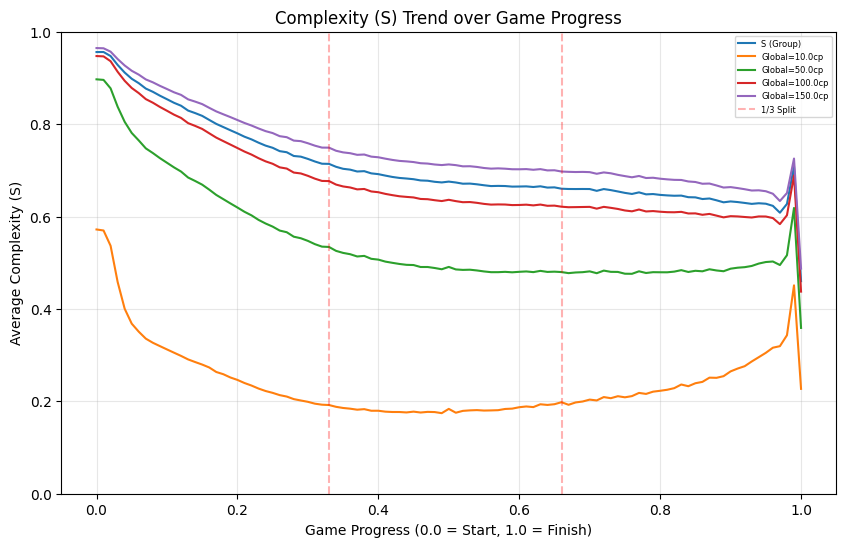

In [28]:
plt.figure(figsize=(10, 6))

# 画 Group-specific S
sns.lineplot(
    x=df_moves['Progress'].round(2),
    y=df_moves['S'],
    estimator='mean',
    errorbar=None,
    label='S (Group)'
)

# 自动找所有 Global S 列
global_s_cols = [col for col in df_moves.columns if col.startswith('S(Global=')]

# 画 Global S
for col in global_s_cols:
    sns.lineplot(
        x=df_moves['Progress'].round(2),
        y=df_moves[col],
        estimator='mean',
        errorbar=None,
        label=col.replace('S(', '').replace(')', '')
    )

plt.ylim(0, 1)
plt.title("Complexity (S) Trend over Game Progress")
plt.xlabel("Game Progress (0.0 = Start, 1.0 = Finish)")
plt.ylabel("Average Complexity (S)")
plt.axvline(0.33, color='r', linestyle='--', alpha=0.3, label='1/3 Split')
plt.axvline(0.66, color='r', linestyle='--', alpha=0.3)
plt.legend(fontsize=6)
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\Administrator\AppData\Local\Temp\ipykernel_33468\668906384.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[-1].legend(fontsize=8, title="ELO Group", loc='upper right')


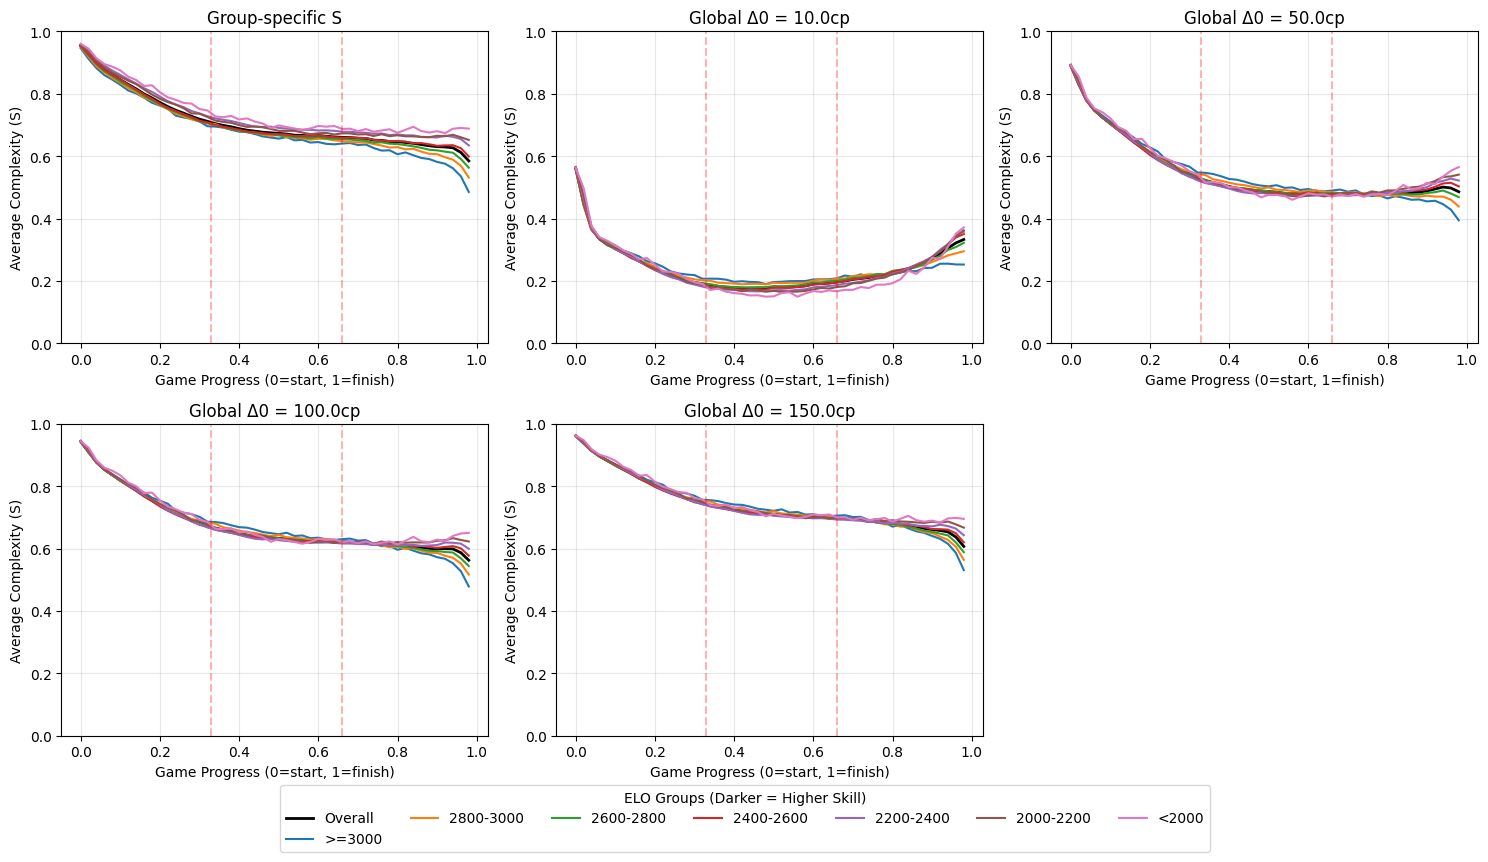

In [62]:
# 分箱
n_bins = 50
df_moves['Progress_bin'] = pd.cut(df_moves['Progress'], bins=n_bins, labels=False)

# 子图网格
n_cols = 3
plot_cols = ['S'] + global_s_cols
n_plots = len(plot_cols)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
palette = sns.color_palette("tab10", n_colors=len(elo_order))

for i, col in enumerate(plot_cols):
    ax = axes[i]

    # 整体平均
    overall_avg = df_moves.groupby('Progress_bin')[col].mean()
    ax.plot(overall_avg.index / n_bins, overall_avg.values, color='black', linewidth=2, label='Overall')

    # 按 ELO 组
    for j, elo in enumerate(elo_order):
        sub_df = df_moves[df_moves['ELO_Group'] == elo]
        group_avg = sub_df.groupby('Progress_bin')[col].mean()
        ax.plot(group_avg.index / n_bins, group_avg.values, color=palette[j], label=str(elo))

    # 标题
    ax.set_title("Group-specific S" if col=='S' else f"Global Δ0 = {col.split('=')[1].replace(')','')}")
    ax.set_xlabel("Game Progress (0=start, 1=finish)")
    ax.set_ylabel("Average Complexity (S)")
    ax.set_ylim(0,1)
    ax.axvline(0.33, color='r', linestyle='--', alpha=0.3)
    ax.axvline(0.66, color='r', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

# 删除多余子图
for j in range(n_plots, len(axes)):
    fig.delaxes(axes[j])

# 图例放在最后一张图
axes[-1].legend(fontsize=8, title="ELO Group", loc='upper right')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
           ncol=len(elo_order), title="ELO Groups (Darker = Higher Skill)", frameon=True)

plt.tight_layout()
plt.show()


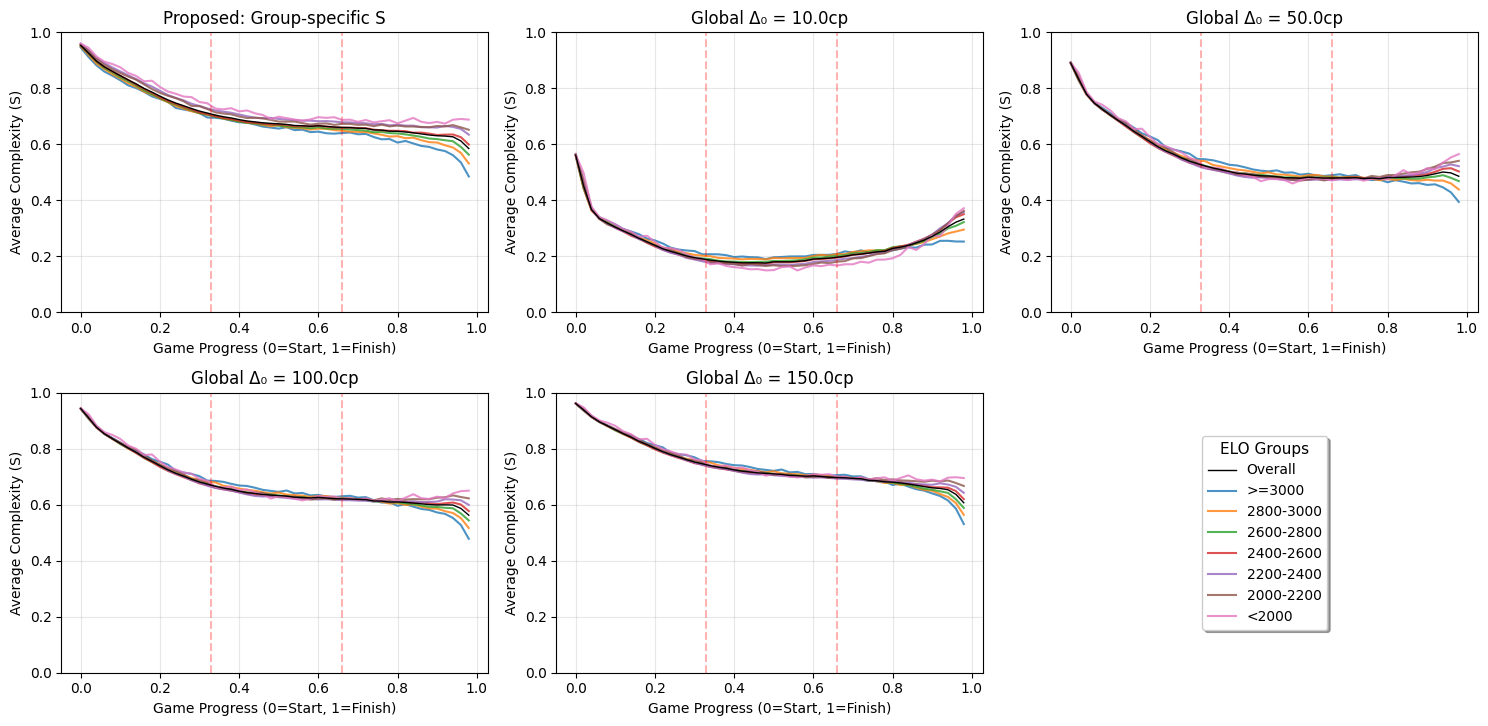

In [67]:
# --- 绘图准备 ---
n_cols = 3
plot_cols = ['S'] + global_s_cols
n_plots = len(plot_cols)
n_rows = math.ceil((n_plots + 1) / n_cols) # 确保为图例留出位置

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = axes.flatten()
palette = sns.color_palette("tab10", n_colors=len(elo_order))

for i, col in enumerate(plot_cols):
    ax = axes[i]
    
    # 整体平均线
    overall_avg = df_moves.groupby('Progress_bin')[col].mean()
    ax.plot(overall_avg.index / n_bins, overall_avg.values, color='black', linewidth=1, label='Overall', zorder=10)

    # 各 ELO 组曲线
    for j, elo in enumerate(elo_order):
        sub_df = df_moves[df_moves['ELO_Group'] == elo]
        group_avg = sub_df.groupby('Progress_bin')[col].mean()
        ax.plot(group_avg.index / n_bins, group_avg.values, color=palette[j], label=str(elo), alpha=0.8)

    # 样式美化
    ax.set_title("Proposed: Group-specific S" if col=='S' else f"Global Δ₀ = {col.split('=')[1].replace(')','')}", fontsize=12)
    ax.set_xlabel("Game Progress (0=Start, 1=Finish)")
    ax.set_ylabel("Average Complexity (S)")
    ax.set_ylim(0, 1)
    ax.axvline(0.33, color='r', linestyle='--', alpha=0.3)
    ax.axvline(0.66, color='r', linestyle='--', alpha=0.3)
    ax.grid(True, alpha=0.3)

# 图例
legend_ax = axes[n_plots] 
legend_ax.axis('off') 
handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', title="ELO Groups", 
                  fontsize=10, title_fontsize=11, frameon=True, shadow=True)

# --- 清理多余的空白子图 ---
for j in range(n_plots + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()